# Complete End-to-End ML Masterclass
## Logistic Regression · Random Forest · Multivariate Forecasting · Feature Engineering · WOE/IV/VIF · Missing Data · Cross-Validation · Time Series

**Zero to Hero AI Training — Week 1 Comprehensive Lab**

This notebook covers:
1. **Synthetic Dataset Generation** — 10,000 rows with realistic patterns
2. **Missing Data Mechanisms** — MCAR, MAR, MNAR with detection & treatment
3. **Feature Engineering** — binning, interactions, WOE encoding, polynomial features
4. **WOE & Information Value (IV)** — predictive power measurement
5. **Multicollinearity & VIF** — detection and handling
6. **Logistic Regression** — every hyperparameter explained with comments
7. **Random Forest** — every hyperparameter explained with comments
8. **10-Fold Stratified Cross-Validation** — robust evaluation
9. **Multivariate Time Series Forecasting** — seasonality, cyclicity, event spikes
10. **Model Comparison & Business Interpretation**


---
## Section 0: Imports & Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, cross_validate,
                                      GridSearchCV, RandomizedSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              log_loss, brier_score_loss, average_precision_score)
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer, KNNImputer

from scipy import stats
from collections import OrderedDict

np.random.seed(42)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

print("All imports loaded successfully ✓")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")


All imports loaded successfully ✓
NumPy: 2.4.3
Pandas: 3.0.1


---
## Section 1: Synthetic Dataset Generation (10,000 rows)

We create a **customer churn dataset** with realistic patterns including:
- Demographic features (age, income, education)
- Behavioral features (tenure, usage, complaints)
- Financial features (monthly charges, total charges, payment delays)
- Temporal features (signup date with seasonality)
- Deliberate multicollinearity, missing data patterns, and class imbalance


In [2]:
n = 10000

# ── Demographics ──
age = np.random.normal(42, 14, n).clip(18, 85).astype(int)
gender = np.random.choice(['Male', 'Female', 'Other'], n, p=[0.48, 0.48, 0.04])
education = np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n, p=[0.35, 0.35, 0.20, 0.10])
marital_status = np.random.choice(['Single', 'Married', 'Divorced'], n, p=[0.35, 0.50, 0.15])

# ── Income (correlated with education — will create multicollinearity) ──
edu_bonus = np.where(education == 'High School', 0,
            np.where(education == 'Bachelor', 15000,
            np.where(education == 'Master', 30000, 50000)))
income = (30000 + edu_bonus + age * 500 + np.random.normal(0, 12000, n)).clip(15000, 250000).round(2)

# ── Behavioral ──
tenure_months = np.random.exponential(24, n).clip(1, 120).astype(int)
monthly_charges = np.random.uniform(20, 150, n).round(2)
total_charges = (monthly_charges * tenure_months * np.random.uniform(0.85, 1.15, n)).round(2)

# total_charges is DELIBERATELY correlated with monthly_charges * tenure → multicollinearity
num_products = np.random.poisson(2, n).clip(1, 8)
support_calls = np.random.poisson(1.5, n).clip(0, 15)
complaints_last_6m = np.random.poisson(0.8, n).clip(0, 10)
avg_monthly_usage_gb = (num_products * 5 + np.random.normal(0, 10, n)).clip(0, 200).round(1)
payment_delay_days = np.random.exponential(5, n).clip(0, 90).round(0).astype(int)

# ── Contract type ──
contract = np.random.choice(['Month-to-month', 'One year', 'Two year'], n, p=[0.50, 0.30, 0.20])

# ── Temporal: signup date with SEASONALITY ──
# More signups in Q1 and Q4 (post-holiday, new year resolutions)
signup_month = np.random.choice(range(1, 13), n,
    p=[0.12, 0.10, 0.09, 0.07, 0.06, 0.06, 0.06, 0.07, 0.08, 0.09, 0.10, 0.10])
signup_year = np.random.choice([2020, 2021, 2022, 2023, 2024, 2025], n,
    p=[0.05, 0.10, 0.15, 0.25, 0.30, 0.15])
signup_date = pd.to_datetime([f'{y}-{m:02d}-{np.random.randint(1,29):02d}'
                               for y, m in zip(signup_year, signup_month)])

# ── Credit Score (correlated with income — multicollinearity) ──
credit_score = (300 + (income - 15000) / 235000 * 550 + np.random.normal(0, 40, n)).clip(300, 850).astype(int)

# ── Target: Churn (complex non-linear relationship) ──
churn_logit = (
    -2.0                                          # base (most don't churn)
    + 0.03 * support_calls                        # more calls → more churn
    + 0.15 * complaints_last_6m                   # complaints strongly predict churn
    + 0.01 * monthly_charges                      # higher cost → more churn
    - 0.02 * tenure_months                        # longer tenure → less churn
    + 0.5 * (contract == 'Month-to-month')        # month-to-month → more churn
    - 0.3 * (contract == 'Two year')              # locked in → less churn
    + 0.005 * payment_delay_days                  # late payers churn more
    - 0.005 * age                                 # older customers slightly more loyal
    - 0.00001 * income                            # higher income → slightly less churn
    + 0.3 * (num_products == 1)                   # single product → more churn
    + np.random.normal(0, 0.3, n)                 # noise
)
churn_prob = 1 / (1 + np.exp(-churn_logit))
churn = (np.random.random(n) < churn_prob).astype(int)

# ── Assemble DataFrame ──
df = pd.DataFrame({
    'customer_id': [f'CUST_{i:05d}' for i in range(n)],
    'age': age, 'gender': gender, 'education': education,
    'marital_status': marital_status, 'income': income,
    'credit_score': credit_score,
    'tenure_months': tenure_months, 'contract': contract,
    'monthly_charges': monthly_charges, 'total_charges': total_charges,
    'num_products': num_products, 'support_calls': support_calls,
    'complaints_last_6m': complaints_last_6m,
    'avg_monthly_usage_gb': avg_monthly_usage_gb,
    'payment_delay_days': payment_delay_days,
    'signup_date': signup_date, 'signup_month': signup_month,
    'signup_year': signup_year,
    'churn': churn
})

print(f"Dataset shape: {df.shape}")
print(f"\nChurn rate: {df['churn'].mean():.2%} (1={df['churn'].sum():,}, 0={(df['churn']==0).sum():,})")
print(f"\nColumn types:\n{df.dtypes.value_counts()}")
df.head()


Dataset shape: (10000, 20)

Churn rate: 14.06% (1=1,406, 0=8,594)

Column types:
int64             10
str                5
float64            4
datetime64[us]     1
Name: count, dtype: int64


,customer_id,age,gender,education,marital_status,income,credit_score,tenure_months,contract,monthly_charges,total_charges,num_products,support_calls,complaints_last_6m,avg_monthly_usage_gb,payment_delay_days,signup_date,signup_month,signup_year,churn
0,CUST_00000,48,Male,High School,Single,64409.1300,447,11,Month-to-month,111.8900,1243.3100,2,0,0,11.1000,1,2024-06-26,6,2024,0
1,CUST_00001,40,Male,High School,Married,39414.7100,332,12,Month-to-month,89.8600,970.2900,3,1,0,11.5000,1,2022-07-07,7,2022,1
2,CUST_00002,51,Male,PhD,Single,92838.6600,500,46,Two year,120.9800,6175.3800,2,0,0,13.6000,14,2020-10-10,10,2020,0
3,CUST_00003,63,Male,Master,Married,88613.0600,480,4,One year,87.1000,303.3100,2,1,1,0.0000,8,2023-06-05,6,2023,1
4,CUST_00004,38,Female,High School,Married,58945.4200,430,24,Two year,61.7600,1311.1200,1,1,1,2.9000,6,2024-01-18,1,2024,0


In [3]:
# ── Quick EDA snapshot ──
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nNumeric columns: {df.select_dtypes(include=[np.number]).columns.tolist()}")
print(f"\nCategorical columns: {df.select_dtypes(include=['object']).columns.tolist()}")
print(f"\nDate columns: {df.select_dtypes(include=['datetime']).columns.tolist()}")
print(f"\nDescriptive statistics:")
df.describe().round(2)


DATASET SUMMARY

Shape: 10,000 rows × 20 columns

Numeric columns: ['age', 'income', 'credit_score', 'tenure_months', 'monthly_charges', 'total_charges', 'num_products', 'support_calls', 'complaints_last_6m', 'avg_monthly_usage_gb', 'payment_delay_days', 'signup_month', 'signup_year', 'churn']

Categorical columns: ['customer_id', 'gender', 'education', 'marital_status', 'contract']

Date columns: ['signup_date']

Descriptive statistics:


,age,income,credit_score,tenure_months,monthly_charges,total_charges,num_products,support_calls,complaints_last_6m,avg_monthly_usage_gb,payment_delay_days,signup_date,signup_month,signup_year,churn
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000,10000.0000,10000.0000,10000.0000
mean,41.7500,66853.5400,421.9900,23.3800,85.1600,1989.6300,2.1200,1.4900,0.8100,11.7300,4.9600,2023-07-26 04:27:15.840000,6.4100,2023.0800,0.1400
min,18.0000,15000.0000,300.0000,1.0000,20.0200,18.5900,1.0000,0.0000,0.0000,0.0000,0.0000,2020-01-01 00:00:00,1.0000,2020.0000,0.0000
25%,32.0000,52210.5600,379.0000,6.0000,53.1400,440.6200,1.0000,1.0000,0.0000,2.5000,1.0000,2022-08-24 12:00:00,3.0000,2022.0000,0.0000
50%,41.0000,65308.2200,419.0000,16.0000,85.1800,1181.3000,2.0000,1.0000,1.0000,10.2000,3.0000,2023-10-25 00:00:00,6.0000,2023.0000,0.0000
75%,51.0000,80115.8000,463.0000,33.0000,117.6100,2654.2800,3.0000,2.0000,1.0000,18.4000,7.0000,2024-09-12 00:00:00,10.0000,2024.0000,0.0000
max,85.0000,146384.7600,702.0000,120.0000,149.9800,18585.1300,8.0000,8.0000,5.0000,60.2000,55.0000,2025-12-28 00:00:00,12.0000,2025.0000,1.0000
std,13.4500,20591.0600,61.8100,23.1500,37.1500,2323.5000,1.2300,1.2200,0.9100,10.2200,5.0100,NaN,3.7800,1.3800,0.3500


---
## Section 2: Missing Data Mechanisms — MCAR, MAR, MNAR

### Theory:
- **MCAR (Missing Completely At Random)**: Missingness has NO relationship with any variable. Example: a survey form gets lost in the mail randomly.
- **MAR (Missing At Random)**: Missingness depends on OTHER observed variables but NOT on the missing value itself. Example: younger people skip the income question (age predicts missingness, not income itself).
- **MNAR (Missing Not At Random)**: Missingness depends on the MISSING VALUE itself. Example: high-income people refuse to report income (the unreported value itself predicts missingness).

### Why this matters:
- MCAR → Simple imputation (mean/median) is unbiased
- MAR → Need model-based imputation (KNN, regression, MICE)
- MNAR → No purely statistical fix; need domain knowledge or sensitivity analysis


In [4]:
# ── Inject MCAR: 5% of 'avg_monthly_usage_gb' randomly missing ──
# MCAR: every row has equal probability of being missing
mcar_mask = np.random.random(n) < 0.05
df.loc[mcar_mask, 'avg_monthly_usage_gb'] = np.nan
print(f"MCAR — avg_monthly_usage_gb: {mcar_mask.sum()} values ({mcar_mask.mean():.1%}) set to NaN")
print(f"  Mechanism: Completely random — no pattern to who is missing")

# ── Inject MAR: income missing more often for younger people ──
# MAR: missingness depends on AGE (observed), not on income itself
mar_prob = np.where(df['age'] < 30, 0.20,     # 20% missing if young
           np.where(df['age'] < 40, 0.10,      # 10% missing if middle
                    0.03))                       # 3% missing if older
mar_mask = np.random.random(n) < mar_prob
df.loc[mar_mask, 'income'] = np.nan
print(f"\nMAR — income: {mar_mask.sum()} values ({mar_mask.mean():.1%}) set to NaN")
print(f"  Mechanism: Young people are more likely to skip income question")
print(f"  Age < 30 missing rate: {mar_mask[df['age'] < 30].mean():.1%}")
print(f"  Age >= 50 missing rate: {mar_mask[df['age'] >= 50].mean():.1%}")

# ── Inject MNAR: credit_score missing for LOW credit scores ──
# MNAR: missingness depends on the VALUE ITSELF (low score → don't report)
mnar_prob = np.where(credit_score < 500, 0.30,   # 30% missing if bad credit
            np.where(credit_score < 600, 0.15,    # 15% if mediocre
                     0.02))                        # 2% if good
mnar_mask = np.random.random(n) < mnar_prob
df.loc[mnar_mask, 'credit_score'] = np.nan
print(f"\nMNAR — credit_score: {mnar_mask.sum()} values ({mnar_mask.mean():.1%}) set to NaN")
print(f"  Mechanism: Low-score people hide their credit score")
print(f"  ⚠️ WARNING: Mean imputation will OVERESTIMATE average credit score!")


MCAR — avg_monthly_usage_gb: 496 values (5.0%) set to NaN
  Mechanism: Completely random — no pattern to who is missing

MAR — income: 825 values (8.2%) set to NaN
  Mechanism: Young people are more likely to skip income question
  Age < 30 missing rate: 20.8%
  Age >= 50 missing rate: 2.8%

MNAR — credit_score: 2825 values (28.2%) set to NaN
  Mechanism: Low-score people hide their credit score
  ⚠️ WARNING: Mean imputation will OVERESTIMATE average credit score!


### Detecting Missing Data Patterns


In [5]:
# ── Missing data summary ──
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct}).query('Count > 0').sort_values('Percentage', ascending=False)
print("Missing Data Summary:")
print(missing_df)

# ── Little's MCAR test approximation ──
# If data is MCAR, missingness should NOT correlate with other variables
# We test: does 'income_missing' correlate with 'age'?
df['income_missing'] = df['income'].isnull().astype(int)
corr_age_income_miss = df['age'].corr(df['income_missing'])
print(f"\nMAR Detection: Correlation(age, income_missing) = {corr_age_income_miss:.4f}")
print(f"  → {'Significant correlation detected — likely MAR (missingness depends on age)' if abs(corr_age_income_miss) > 0.05 else 'Weak correlation — may be MCAR'}")

# MNAR detection: compare distributions
df['credit_missing'] = df['credit_score'].isnull().astype(int)
# We can't directly compare (the missing values are missing!), but we can check
# if missingness correlates with RELATED variables
corr_income_credit_miss = df['income'].corr(df['credit_missing'])
print(f"\nMNAR Hint: Correlation(income, credit_missing) = {corr_income_credit_miss:.4f}")
print(f"  → Low-income (correlated with low credit) people have more missing credit scores")

df.drop(['income_missing', 'credit_missing'], axis=1, inplace=True)


Missing Data Summary:
                      Count  Percentage
credit_score           2825     28.2500
income                  825      8.2500
avg_monthly_usage_gb    496      4.9600

MAR Detection: Correlation(age, income_missing) = -0.2123
  → Significant correlation detected — likely MAR (missingness depends on age)

MNAR Hint: Correlation(income, credit_missing) = -0.0575
  → Low-income (correlated with low credit) people have more missing credit scores


### Imputation Strategies


In [6]:
# ── Strategy 1: MCAR → Median imputation (unbiased for MCAR) ──
usage_median = df['avg_monthly_usage_gb'].median()
df['avg_monthly_usage_gb'] = df['avg_monthly_usage_gb'].fillna(usage_median)
print(f"MCAR (usage): Filled with median = {usage_median:.1f} GB")

# ── Strategy 2: MAR → KNN Imputer (uses age and other features to predict income) ──
# KNN finds the k nearest neighbors based on non-missing features and averages their income
from sklearn.impute import KNNImputer

impute_features = ['age', 'monthly_charges', 'tenure_months', 'num_products']
income_col_idx = 0  # income will be first column

knn_df = df[['income'] + impute_features].copy()
knn_imputer = KNNImputer(
    n_neighbors=5,        # Use 5 nearest neighbors
    weights='distance',   # Weight by inverse distance (closer neighbors matter more)
    metric='nan_euclidean' # Handle NaN in distance calculation
)
knn_result = knn_imputer.fit_transform(knn_df)
income_before_impute = df['income'].isnull().sum()
df['income'] = knn_result[:, 0].round(2)
print(f"\nMAR (income): KNN imputed {income_before_impute} values using {impute_features}")

# ── Strategy 3: MNAR → Flag + conditional imputation ──
# For MNAR, we MUST create a missingness indicator (the fact it's missing IS information)
df['credit_score_missing_flag'] = df['credit_score'].isnull().astype(int)
# Impute with CONDITIONAL median (by education group, since credit correlates with education)
credit_medians = df.groupby('education')['credit_score'].transform('median')
df['credit_score'] = df['credit_score'].fillna(credit_medians)
# If still NaN (all in group were NaN), use global median
df['credit_score'] = df['credit_score'].fillna(df['credit_score'].median())
print(f"MNAR (credit): Conditional median imputation + missingness flag created")
print(f"  ⚠️ credit_score_missing_flag = 1 means 'likely low credit score'")

print(f"\nRemaining missing values: {df.isnull().sum().sum()}")


MCAR (usage): Filled with median = 10.2 GB

MAR (income): KNN imputed 825 values using ['age', 'monthly_charges', 'tenure_months', 'num_products']
MNAR (credit): Conditional median imputation + missingness flag created
  ⚠️ credit_score_missing_flag = 1 means 'likely low credit score'

Remaining missing values: 0

MAR (income): KNN imputed 825 values using ['age', 'monthly_charges', 'tenure_months', 'num_products']
MNAR (credit): Conditional median imputation + missingness flag created
  ⚠️ credit_score_missing_flag = 1 means 'likely low credit score'

Remaining missing values: 0


---
## Section 3: Feature Engineering

Transform raw data into predictive features. Every engineered feature should have a **business hypothesis** behind it.


In [7]:
# ═══════════════════════════════════════════════════════════════
# 3.1 NUMERICAL BINNING — Convert continuous to categorical
# ═══════════════════════════════════════════════════════════════

# Age bins (life stages have different churn behavior)
df['age_group'] = pd.cut(df['age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])

# Tenure bins (loyalty tiers)
df['tenure_group'] = pd.cut(df['tenure_months'],
    bins=[0, 6, 12, 24, 48, 200],
    labels=['0-6m', '7-12m', '1-2y', '2-4y', '4y+'])

# Income quartiles
df['income_quartile'] = pd.qcut(df['income'], q=4, labels=['Q1_Low', 'Q2_Mid', 'Q3_High', 'Q4_Top'])

print("Binned features created:")
print(f"  age_group: {df['age_group'].value_counts().to_dict()}")
print(f"  tenure_group: {df['tenure_group'].value_counts().to_dict()}")


Binned features created:
  age_group: {'36-45': 2767, '46-55': 2282, '26-35': 2093, '18-25': 1265, '56-65': 1169, '65+': 424}
  tenure_group: {'0-6m': 2505, '1-2y': 2267, '2-4y': 2263, '7-12m': 1683, '4y+': 1282}


In [8]:
# ═══════════════════════════════════════════════════════════════
# 3.2 INTERACTION FEATURES — Capture joint effects
# ═══════════════════════════════════════════════════════════════

# Charges per month of tenure (are they paying more per unit time?)
df['charges_per_tenure'] = (df['monthly_charges'] / df['tenure_months'].clip(1)).round(2)

# Usage efficiency (GB per dollar)
df['usage_per_dollar'] = (df['avg_monthly_usage_gb'] / df['monthly_charges'].clip(1)).round(4)

# Complaint intensity (complaints per month of tenure)
df['complaint_rate'] = (df['complaints_last_6m'] / df['tenure_months'].clip(1) * 12).round(4)

# Support burden (calls per product)
df['support_per_product'] = (df['support_calls'] / df['num_products']).round(2)

# Financial stress indicator
df['financial_stress'] = ((df['payment_delay_days'] > 30) &
                           (df['monthly_charges'] > df['monthly_charges'].median())).astype(int)

# Engagement score (multi-product + long tenure + low complaints)
df['engagement_score'] = (
    (df['num_products'] / df['num_products'].max()) * 0.3 +
    (df['tenure_months'] / df['tenure_months'].max()) * 0.4 +
    (1 - df['complaints_last_6m'] / df['complaints_last_6m'].max()) * 0.3
).round(4)

print("Interaction features created:")
for col in ['charges_per_tenure', 'usage_per_dollar', 'complaint_rate',
            'support_per_product', 'financial_stress', 'engagement_score']:
    print(f"  {col}: mean={df[col].mean():.4f}, std={df[col].std():.4f}")


Interaction features created:
  charges_per_tenure: mean=14.7588, std=25.8701
  usage_per_dollar: mean=0.1796, std=0.2107
  complaint_rate: mean=1.6931, std=4.3662
  support_per_product: mean=0.9513, std=0.9754
  financial_stress: mean=0.0010, std=0.0316
  engagement_score: mean=0.4086, std=0.1049


In [9]:
# ═══════════════════════════════════════════════════════════════
# 3.3 TEMPORAL FEATURES — Extract patterns from dates
# ═══════════════════════════════════════════════════════════════

# Is it a Q4 signup? (holiday season customers may behave differently)
df['is_q4_signup'] = (df['signup_month'].isin([10, 11, 12])).astype(int)

# Season of signup
df['signup_season'] = df['signup_month'].map({
    1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring', 6: 'Summer',
    7: 'Summer', 8: 'Summer', 9: 'Autumn', 10: 'Autumn', 11: 'Autumn', 12: 'Winter'
})

# Cyclical encoding of month (preserves Dec→Jan proximity)
df['signup_month_sin'] = np.sin(2 * np.pi * df['signup_month'] / 12).round(4)
df['signup_month_cos'] = np.cos(2 * np.pi * df['signup_month'] / 12).round(4)

print("Temporal features created:")
print(f"  Q4 signups: {df['is_q4_signup'].sum()} ({df['is_q4_signup'].mean():.1%})")
print(f"  Season distribution: {df['signup_season'].value_counts().to_dict()}")
print(f"  Cyclical encoding sample (month 1): sin={np.sin(2*np.pi*1/12):.4f}, cos={np.cos(2*np.pi*1/12):.4f}")
print(f"  Cyclical encoding sample (month 12): sin={np.sin(2*np.pi*12/12):.4f}, cos={np.cos(2*np.pi*12/12):.4f}")


Temporal features created:
  Q4 signups: 2871 (28.7%)
  Season distribution: {'Winter': 3258, 'Autumn': 2724, 'Spring': 2171, 'Summer': 1847}
  Cyclical encoding sample (month 1): sin=0.5000, cos=0.8660
  Cyclical encoding sample (month 12): sin=-0.0000, cos=1.0000


In [10]:
# ═══════════════════════════════════════════════════════════════
# 3.4 ENCODING CATEGORICAL VARIABLES
# ═══════════════════════════════════════════════════════════════

# Label encoding for ordinal features
education_order = {'High School': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4}
df['education_encoded'] = df['education'].map(education_order)

# One-hot encoding for nominal features
df_encoded = pd.get_dummies(df, columns=['gender', 'contract', 'marital_status', 'signup_season'],
                            drop_first=True, dtype=int)

print(f"After encoding: {df_encoded.shape[1]} columns (was {df.shape[1]})")
new_cols = [c for c in df_encoded.columns if c not in df.columns]
print(f"New one-hot columns: {new_cols}")


After encoding: 40 columns (was 35)
New one-hot columns: ['gender_Male', 'gender_Other', 'contract_One year', 'contract_Two year', 'marital_status_Married', 'marital_status_Single', 'signup_season_Spring', 'signup_season_Summer', 'signup_season_Winter']


In [11]:
display(df_encoded.head())

,customer_id,age,education,income,credit_score,tenure_months,monthly_charges,total_charges,num_products,support_calls,complaints_last_6m,avg_monthly_usage_gb,payment_delay_days,signup_date,signup_month,signup_year,churn,credit_score_missing_flag,age_group,tenure_group,income_quartile,charges_per_tenure,usage_per_dollar,complaint_rate,support_per_product,financial_stress,engagement_score,is_q4_signup,signup_month_sin,signup_month_cos,education_encoded,gender_Male,gender_Other,contract_One year,contract_Two year,marital_status_Married,marital_status_Single,signup_season_Spring,signup_season_Summer,signup_season_Winter
0,CUST_00000,48,High School,64409.1300,447.0000,11,111.8900,1243.3100,2,0,0,11.1000,1,2024-06-26,6,2024,0,0,46-55,7-12m,Q2_Mid,10.1700,0.0992,0.0000,0.0000,0,0.4117,0,0.0000,-1.0000,1,1,0,0,0,0,1,0,1,0
1,CUST_00001,40,High School,39414.7100,386.0000,12,89.8600,970.2900,3,1,0,11.5000,1,2022-07-07,7,2022,1,1,36-45,7-12m,Q1_Low,7.4900,0.1280,0.0000,0.3300,0,0.4525,0,-0.5000,-0.8660,1,1,0,0,0,1,0,0,1,0
2,CUST_00002,51,PhD,92838.6600,500.0000,46,120.9800,6175.3800,2,0,0,13.6000,14,2020-10-10,10,2020,0,0,46-55,2-4y,Q4_Top,2.6300,0.1124,0.0000,0.0000,0,0.5283,1,-0.8660,0.5000,4,1,0,0,1,0,1,0,0,0
3,CUST_00003,63,Master,88613.0600,457.0000,4,87.1000,303.3100,2,1,1,0.0000,8,2023-06-05,6,2023,1,1,56-65,0-6m,Q4_Top,21.7800,0.0000,3.0000,0.5000,0,0.3283,0,0.0000,-1.0000,3,1,0,1,0,1,0,0,1,0
4,CUST_00004,38,High School,58945.4200,430.0000,24,61.7600,1311.1200,1,1,1,2.9000,6,2024-01-18,1,2024,0,0,36-45,1-2y,Q2_Mid,2.5700,0.0470,0.5000,1.0000,0,0.3575,0,0.5000,0.8660,1,0,0,0,1,1,0,0,0,1


---
## Section 4: Weight of Evidence (WOE) & Information Value (IV)

### Theory:
- **WOE** = ln(% of Events / % of Non-Events) for each bin of a feature
  - Positive WOE → bin has more non-events (good customers)
  - Negative WOE → bin has more events (churners)
  - WOE transforms features into a scale that shows predictive direction

- **IV** = Σ (% Events - % Non-Events) × WOE  across all bins
  - IV < 0.02 → Useless predictor
  - 0.02 < IV < 0.1 → Weak predictor
  - 0.1 < IV < 0.3 → Medium predictor
  - 0.3 < IV < 0.5 → Strong predictor
  - IV > 0.5 → Suspicious (overfitting or data leakage)


In [12]:
def calculate_woe_iv(df, feature, target, bins=10):
    """
    Calculate Weight of Evidence (WOE) and Information Value (IV)
    for a given feature against a binary target.

    Parameters:
    -----------
    df : DataFrame
    feature : str — column name of the predictor
    target : str — column name of binary target (0/1)
    bins : int — number of bins for continuous features

    Returns:
    --------
    DataFrame with WOE per bin, and total IV
    """
    data = df[[feature, target]].copy()

    # Bin continuous variables
    if data[feature].nunique() > bins:
        data['bin'] = pd.qcut(data[feature], q=bins, duplicates='drop')
    else:
        data['bin'] = data[feature]

    # Count events (churn=1) and non-events (churn=0) per bin
    grouped = data.groupby('bin', observed=True)[target].agg(['sum', 'count'])
    grouped.columns = ['events', 'total']
    grouped['non_events'] = grouped['total'] - grouped['events']

    # Calculate distributions
    total_events = grouped['events'].sum()
    total_non_events = grouped['non_events'].sum()

    # Avoid division by zero with small constant
    grouped['pct_events'] = (grouped['events'] / total_events).clip(0.0001)
    grouped['pct_non_events'] = (grouped['non_events'] / total_non_events).clip(0.0001)

    # WOE = ln(% non-events / % events)
    # Positive → good bin (more non-events), Negative → bad bin (more events)
    grouped['woe'] = np.log(grouped['pct_non_events'] / grouped['pct_events'])

    # IV contribution per bin
    grouped['iv_component'] = (grouped['pct_non_events'] - grouped['pct_events']) * grouped['woe']

    total_iv = grouped['iv_component'].sum()

    return grouped, total_iv


# ── Calculate IV for all numeric features ──
numeric_features = ['age', 'income', 'tenure_months', 'monthly_charges', 'total_charges',
                    'num_products', 'support_calls', 'complaints_last_6m',
                    'avg_monthly_usage_gb', 'payment_delay_days', 'credit_score',
                    'charges_per_tenure', 'complaint_rate', 'engagement_score']

iv_results = {}
for feat in numeric_features:
    _, iv = calculate_woe_iv(df, feat, 'churn', bins=10)
    iv_results[feat] = round(iv, 4)

iv_df = pd.DataFrame.from_dict(iv_results, orient='index', columns=['IV']).sort_values('IV', ascending=False)
iv_df['Predictive Power'] = iv_df['IV'].apply(
    lambda x: '🔴 Suspicious (>0.5)' if x > 0.5 else
              '🟢 Strong (0.3-0.5)' if x > 0.3 else
              '🟡 Medium (0.1-0.3)' if x > 0.1 else
              '🟠 Weak (0.02-0.1)' if x > 0.02 else
              '⚪ Useless (<0.02)')

print("INFORMATION VALUE RANKING")
print("=" * 60)
print(iv_df.to_string())


INFORMATION VALUE RANKING
                         IV    Predictive Power
charges_per_tenure   0.2434  🟡 Medium (0.1-0.3)
tenure_months        0.1500  🟡 Medium (0.1-0.3)
engagement_score     0.1486  🟡 Medium (0.1-0.3)
monthly_charges      0.1225  🟡 Medium (0.1-0.3)
complaint_rate       0.0739   🟠 Weak (0.02-0.1)
total_charges        0.0595   🟠 Weak (0.02-0.1)
income               0.0423   🟠 Weak (0.02-0.1)
age                  0.0329   🟠 Weak (0.02-0.1)
num_products         0.0263   🟠 Weak (0.02-0.1)
credit_score         0.0235   🟠 Weak (0.02-0.1)
complaints_last_6m   0.0108   ⚪ Useless (<0.02)
support_calls        0.0064   ⚪ Useless (<0.02)
avg_monthly_usage_gb 0.0064   ⚪ Useless (<0.02)
payment_delay_days   0.0049   ⚪ Useless (<0.02)



Detailed WOE for 'charges_per_tenure' (IV = 0.2434)
                  events  non_events     woe  iv_component
bin                                                       
(0.169, 1.15]         46         960  1.2280        0.0970
(1.15, 1.85]          85         915  0.5660        0.0260
(1.85, 2.65]         109         887  0.2862        0.0074
(2.65, 3.58]          99         902  0.3992        0.0138
(3.58, 4.88]         127         874  0.1186        0.0013
(4.88, 6.86]         161         837 -0.1619        0.0028
(6.86, 10.193]       154         844 -0.1091        0.0012
(10.193, 17.1]       164         837 -0.1804        0.0035
(17.1, 39.787]       225         774 -0.5748        0.0402
(39.787, 149.93]     236         764 -0.6356        0.0502


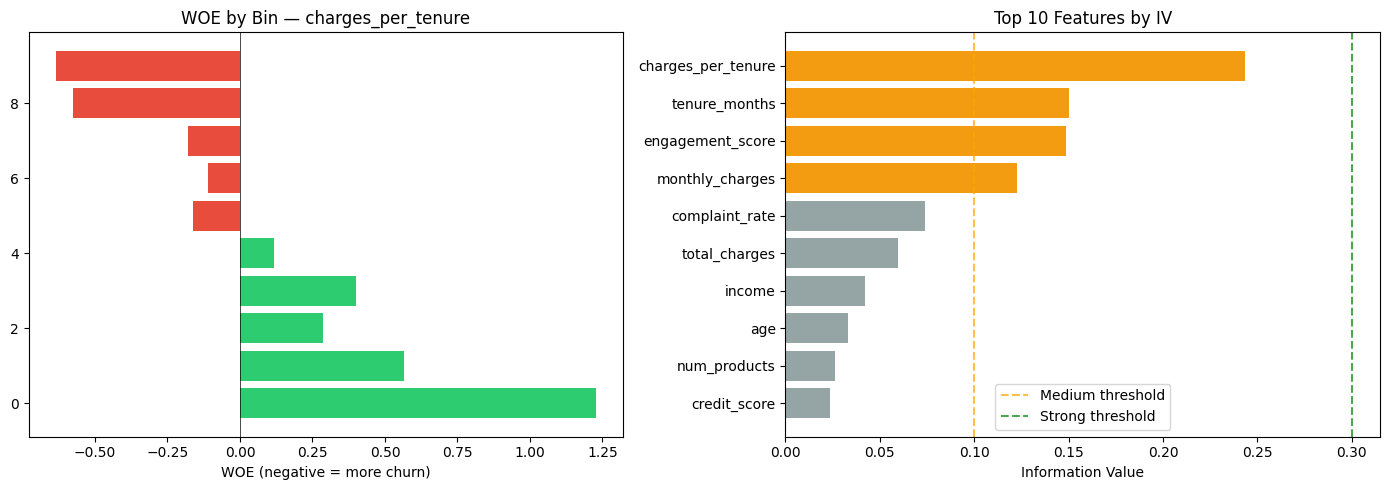

In [13]:
# ── Detailed WOE for top predictor ──
top_feature = iv_df.index[0]
woe_detail, iv = calculate_woe_iv(df, top_feature, 'churn', bins=10)

print(f"\nDetailed WOE for '{top_feature}' (IV = {iv:.4f})")
print("=" * 70)
print(woe_detail[['events', 'non_events', 'woe', 'iv_component']].round(4).to_string())

# ── Visualize WOE ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# WOE bars
woe_vals = woe_detail['woe'].values
colors = ['#e74c3c' if w < 0 else '#2ecc71' for w in woe_vals]
axes[0].barh(range(len(woe_vals)), woe_vals, color=colors)
axes[0].set_xlabel('WOE (negative = more churn)')
axes[0].set_title(f'WOE by Bin — {top_feature}')
axes[0].axvline(x=0, color='black', linewidth=0.5)

# IV ranking
top_10_iv = iv_df.head(10)
colors_iv = ['#e74c3c' if iv > 0.5 else '#2ecc71' if iv > 0.3 else '#f39c12' if iv > 0.1 else '#95a5a6'
             for iv in top_10_iv['IV']]
axes[1].barh(top_10_iv.index[::-1], top_10_iv['IV'].values[::-1], color=colors_iv[::-1])
axes[1].set_xlabel('Information Value')
axes[1].set_title('Top 10 Features by IV')
axes[1].axvline(x=0.1, color='orange', linestyle='--', alpha=0.7, label='Medium threshold')
axes[1].axvline(x=0.3, color='green', linestyle='--', alpha=0.7, label='Strong threshold')
axes[1].legend()

plt.tight_layout()
plt.show()


In [14]:
# ═══════════════════════════════════════════════════════════════
# 4.2 WOE ENCODING — Transform features using their WOE values
# ═══════════════════════════════════════════════════════════════
# WOE encoding replaces each bin with its WOE value
# This is especially useful for Logistic Regression

def woe_encode(df, feature, target, bins=10):
    """Replace feature values with their WOE scores."""
    data = df[[feature, target]].copy()
    if data[feature].nunique() > bins:
        data['bin'] = pd.qcut(data[feature], q=bins, duplicates='drop')
    else:
        data['bin'] = data[feature]

    grouped = data.groupby('bin', observed=True)[target].agg(['sum', 'count'])
    grouped.columns = ['events', 'total']
    grouped['non_events'] = grouped['total'] - grouped['events']
    total_e = grouped['events'].sum()
    total_ne = grouped['non_events'].sum()
    grouped['woe'] = np.log((grouped['non_events']/total_ne).clip(0.0001) / (grouped['events']/total_e).clip(0.0001))

    woe_map = grouped['woe'].to_dict()

    if data[feature].nunique() > bins:
        df[f'{feature}_woe'] = pd.qcut(df[feature], q=bins, duplicates='drop').map(woe_map)
    else:
        df[f'{feature}_woe'] = df[feature].map(woe_map)
    return df

# WOE encode top predictors
for feat in ['tenure_months', 'complaints_last_6m', 'monthly_charges', 'support_calls']:
    df = woe_encode(df, feat, 'churn', bins=10)
    print(f"  WOE encoded: {feat} → {feat}_woe")

print(f"\nWOE columns added: {[c for c in df.columns if c.endswith('_woe')]}")


  WOE encoded: tenure_months → tenure_months_woe
  WOE encoded: complaints_last_6m → complaints_last_6m_woe
  WOE encoded: monthly_charges → monthly_charges_woe
  WOE encoded: support_calls → support_calls_woe

WOE columns added: ['tenure_months_woe', 'complaints_last_6m_woe', 'monthly_charges_woe', 'support_calls_woe']


---
## Section 5: Multicollinearity & VIF (Variance Inflation Factor)

### Theory:
- **Multicollinearity**: When two or more predictors are highly correlated, making it hard to isolate individual effects.
- **VIF** = 1 / (1 - R²) where R² is from regressing feature X on all other features.
  - VIF = 1 → No multicollinearity
  - VIF 1-5 → Low to moderate
  - VIF 5-10 → High — consider removing
  - VIF > 10 → Very high — MUST address

### Why it matters:
- Logistic Regression coefficients become **unstable** and **uninterpretable**
- Standard errors inflate → p-values become unreliable
- Random Forest is NOT affected (tree splits don't care about correlations)


In [15]:
from sklearn.linear_model import LinearRegression

def calculate_vif(df, features):
    """
    Calculate Variance Inflation Factor for each feature.
    VIF_i = 1 / (1 - R²_i) where R²_i is from regressing feature_i on all others.
    """
    vif_data = []
    X = df[features].values

    for i, feat in enumerate(features):
        # Regress feature_i on all other features
        X_other = np.delete(X, i, axis=1)
        y_feat = X[:, i]

        # Remove NaN rows
        mask = ~np.isnan(y_feat) & ~np.any(np.isnan(X_other), axis=1)
        if mask.sum() < 10:
            vif_data.append({'Feature': feat, 'VIF': np.nan, 'R²': np.nan})
            continue

        lr = LinearRegression()
        lr.fit(X_other[mask], y_feat[mask])
        r2 = lr.score(X_other[mask], y_feat[mask])
        vif = 1 / (1 - r2) if r2 < 1 else float('inf')
        vif_data.append({'Feature': feat, 'VIF': round(vif, 2), 'R²': round(r2, 4)})

    return pd.DataFrame(vif_data).sort_values('VIF', ascending=False)


# ── Calculate VIF for key numeric features ──
vif_features = ['age', 'income', 'credit_score', 'tenure_months', 'monthly_charges',
                'total_charges', 'num_products', 'support_calls', 'complaints_last_6m',
                'avg_monthly_usage_gb', 'payment_delay_days']

vif_df = calculate_vif(df, vif_features)
vif_df['Status'] = vif_df['VIF'].apply(
    lambda x: '🔴 VERY HIGH (>10)' if x > 10 else
              '🟠 HIGH (5-10)' if x > 5 else
              '🟡 MODERATE (2-5)' if x > 2 else
              '🟢 LOW (<2)')

print("VARIANCE INFLATION FACTOR ANALYSIS")
print("=" * 70)
print(vif_df.to_string(index=False))
print("\n⚠️ Features with VIF > 5 should be reviewed for multicollinearity")


VARIANCE INFLATION FACTOR ANALYSIS
             Feature    VIF     R²           Status
       total_charges 6.9700 0.8565    🟠 HIGH (5-10)
       tenure_months 6.0100 0.8335    🟠 HIGH (5-10)
              income 2.3000 0.5657 🟡 MODERATE (2-5)
        credit_score 2.1300 0.5313 🟡 MODERATE (2-5)
     monthly_charges 1.9700 0.4920       🟢 LOW (<2)
        num_products 1.4000 0.2844       🟢 LOW (<2)
avg_monthly_usage_gb 1.4000 0.2852       🟢 LOW (<2)
                 age 1.1300 0.1161       🟢 LOW (<2)
       support_calls 1.0000 0.0010       🟢 LOW (<2)
  complaints_last_6m 1.0000 0.0007       🟢 LOW (<2)
  payment_delay_days 1.0000 0.0013       🟢 LOW (<2)

⚠️ Features with VIF > 5 should be reviewed for multicollinearity


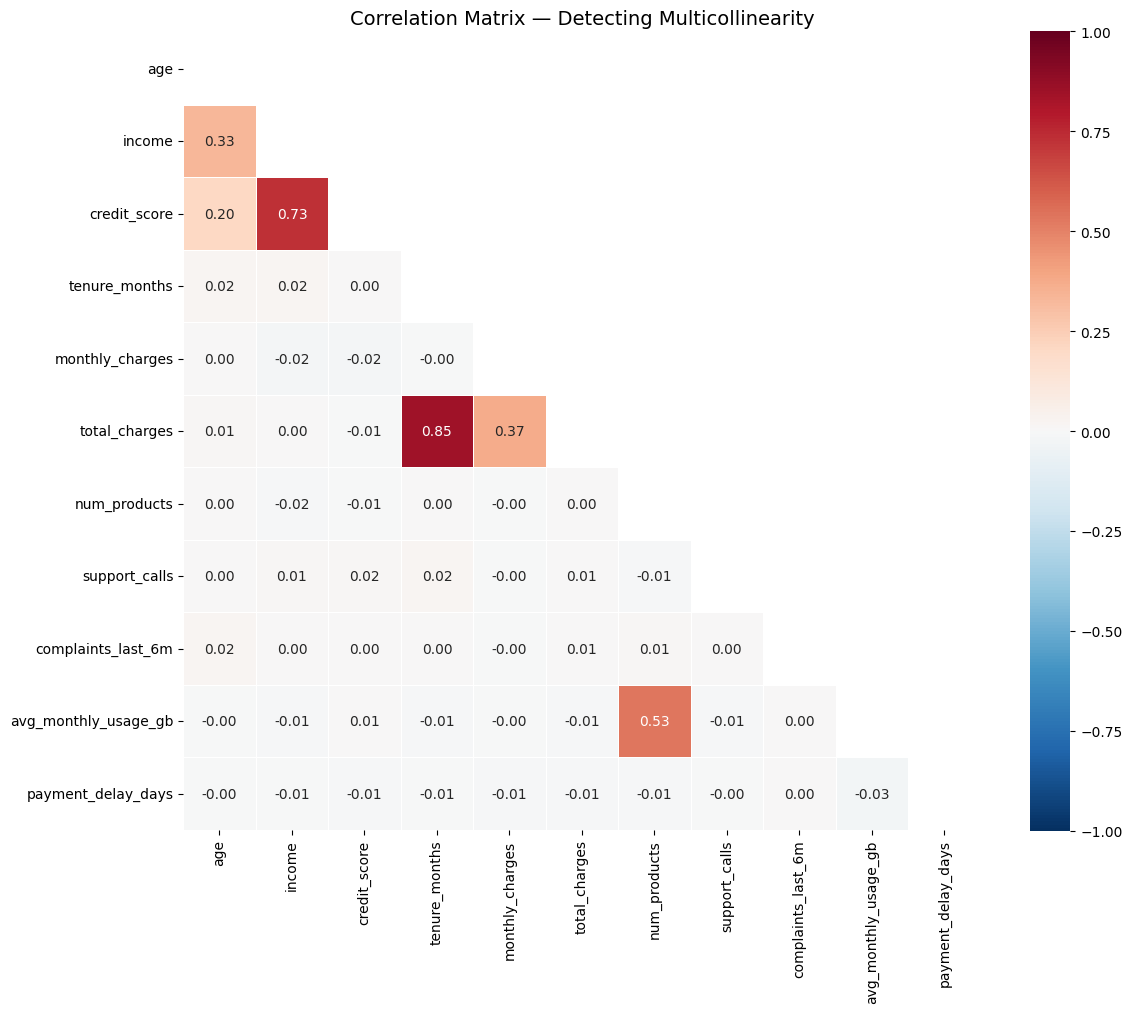


Highly Correlated Pairs (|r| > 0.7):
  income ↔ credit_score: r = 0.727 ⚠️
  tenure_months ↔ total_charges: r = 0.847 ⚠️


In [16]:
# ── Correlation heatmap to visualize multicollinearity ──
corr_features = vif_features
corr_matrix = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Matrix — Detecting Multicollinearity', fontsize=14)
plt.tight_layout()
plt.show()

# ── Identify highly correlated pairs ──
print("\nHighly Correlated Pairs (|r| > 0.7):")
for i in range(len(corr_features)):
    for j in range(i+1, len(corr_features)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {corr_features[i]} ↔ {corr_features[j]}: r = {r:.3f} ⚠️")


In [17]:
# ═══════════════════════════════════════════════════════════════
# HANDLING MULTICOLLINEARITY
# ═══════════════════════════════════════════════════════════════

# Strategy: Drop total_charges (it's monthly_charges × tenure — redundant)
# We already captured the interaction via 'charges_per_tenure'
print("Resolution:")
print("  1. DROP total_charges (derived from monthly_charges × tenure)")
print("  2. KEEP income and credit_score (despite correlation, both have business meaning)")
print("  3. Use the engineered 'charges_per_tenure' instead")

# ── Recalculate VIF after dropping total_charges ──
vif_features_clean = [f for f in vif_features if f != 'total_charges']
vif_clean = calculate_vif(df, vif_features_clean)
print(f"\nVIF after removing total_charges:")
print(vif_clean[['Feature', 'VIF']].to_string(index=False))


Resolution:
  1. DROP total_charges (derived from monthly_charges × tenure)
  2. KEEP income and credit_score (despite correlation, both have business meaning)
  3. Use the engineered 'charges_per_tenure' instead

VIF after removing total_charges:
             Feature    VIF
              income 2.3000
        credit_score 2.1300
        num_products 1.4000
avg_monthly_usage_gb 1.4000
                 age 1.1300
       tenure_months 1.0000
     monthly_charges 1.0000
       support_calls 1.0000
  complaints_last_6m 1.0000
  payment_delay_days 1.0000


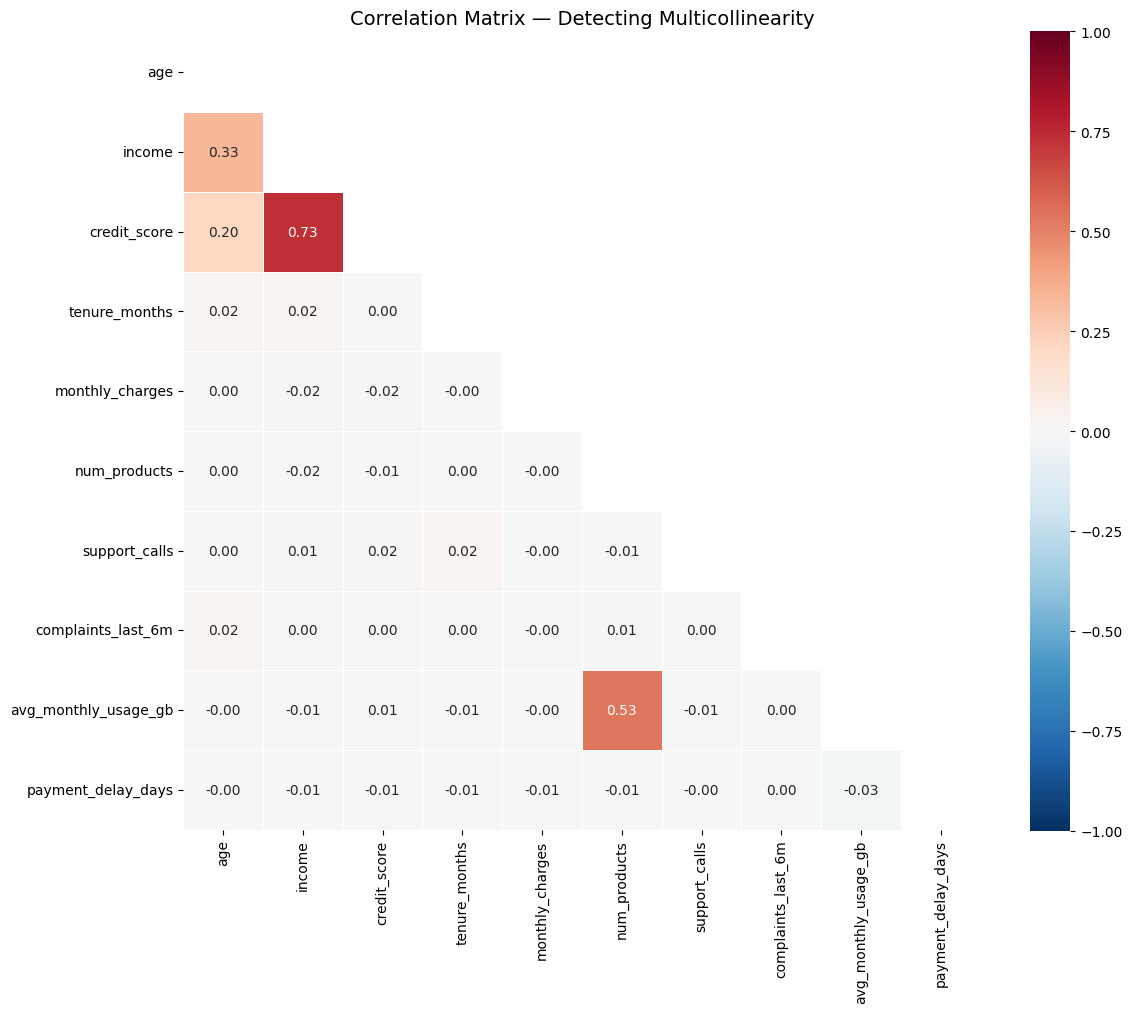


Highly Correlated Pairs (|r| > 0.7):
  income ↔ credit_score: r = 0.727 ⚠️


In [18]:
# ── Correlation heatmap to visualize multicollinearity ──
corr_features = vif_features_clean
corr_matrix = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Matrix — Detecting Multicollinearity', fontsize=14)
plt.tight_layout()
plt.show()

# ── Identify highly correlated pairs ──
print("\nHighly Correlated Pairs (|r| > 0.7):")
for i in range(len(corr_features)):
    for j in range(i+1, len(corr_features)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {corr_features[i]} ↔ {corr_features[j]}: r = {r:.3f} ⚠️")


---
## Section 6: Prepare Final Modeling Dataset


In [19]:
# ── Select features for modeling ──
feature_columns = [
    # Original numeric (excluding total_charges due to multicollinearity)
    'age', 'income', 'credit_score', 'tenure_months', 'monthly_charges',
    'num_products', 'support_calls', 'complaints_last_6m',
    'avg_monthly_usage_gb', 'payment_delay_days',

    # Engineered features
    'charges_per_tenure', 'usage_per_dollar', 'complaint_rate',
    'support_per_product', 'financial_stress', 'engagement_score',
    'education_encoded', 'credit_score_missing_flag',
    'is_q4_signup', 'signup_month_sin', 'signup_month_cos',

    # One-hot encoded
    'gender_Male', 'gender_Other',
    'contract_One year', 'contract_Two year',
    'marital_status_Married', 'marital_status_Single',
]

# Filter to columns that exist in df_encoded
available_features = [c for c in feature_columns if c in df_encoded.columns]
print(f"Using {len(available_features)} features for modeling")

X = df_encoded[available_features].copy()
y = df_encoded['churn'].copy()

# ── Handle any remaining NaN/inf ──
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

# ── Scale features ──
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# ── Train/Test split (stratified to preserve churn ratio) ──
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]:,} rows, Churn rate: {y_train.mean():.2%}")
print(f"Test set:  {X_test.shape[0]:,} rows, Churn rate: {y_test.mean():.2%}")
print(f"\nFeatures: {available_features}")


Using 27 features for modeling

Train set: 8,000 rows, Churn rate: 14.06%
Test set:  2,000 rows, Churn rate: 14.05%

Features: ['age', 'income', 'credit_score', 'tenure_months', 'monthly_charges', 'num_products', 'support_calls', 'complaints_last_6m', 'avg_monthly_usage_gb', 'payment_delay_days', 'charges_per_tenure', 'usage_per_dollar', 'complaint_rate', 'support_per_product', 'financial_stress', 'engagement_score', 'education_encoded', 'credit_score_missing_flag', 'is_q4_signup', 'signup_month_sin', 'signup_month_cos', 'gender_Male', 'gender_Other', 'contract_One year', 'contract_Two year', 'marital_status_Married', 'marital_status_Single']


---
## Section 7: Logistic Regression — Every Hyperparameter Explained

Logistic Regression models the **log-odds** of the target:
$$\log\left(\frac{P(y=1)}{1-P(y=1)}\right) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots$$

Each coefficient β represents the **change in log-odds** for a one-unit increase in that feature.


In [20]:
# ═══════════════════════════════════════════════════════════════
# LOGISTIC REGRESSION WITH EVERY HYPERPARAMETER COMMENTED
# ═══════════════════════════════════════════════════════════════

lr_model = LogisticRegression(

    # ── PENALTY (Regularisation type) ──
    # 'l1' = Lasso: drives weak coefficients to EXACTLY 0 (feature selection)
    # 'l2' = Ridge: shrinks all coefficients but keeps all features (DEFAULT)
    # 'elasticnet' = Mix of L1+L2 (requires l1_ratio parameter)
    # None = No regularisation (risk of overfitting)
    penalty='l2',

    # ── C (Inverse of regularisation strength) ──
    # SMALLER C = STRONGER regularisation (more penalty for large coefficients)
    # LARGER C = WEAKER regularisation (model can fit training data more freely)
    # C=1.0 is default. Try [0.001, 0.01, 0.1, 1, 10, 100]
    C=0.1,

    # ── SOLVER (Optimisation algorithm) ──
    # 'lbfgs' = Limited-memory BFGS (DEFAULT, good for small-medium datasets)
    # 'liblinear' = Coordinate descent (good for small datasets, supports L1)
    # 'newton-cg' = Newton conjugate gradient (good for multiclass)
    # 'sag' = Stochastic Average Gradient (fast for large datasets)
    # 'saga' = Variant of SAG (supports ALL penalties, good for large data + L1)
    solver='lbfgs',

    # ── MAX_ITER (Maximum iterations for solver to converge) ──
    # If you get "ConvergenceWarning", INCREASE this value
    # Default=100, increase to 500-1000 for complex datasets
    max_iter=1000,

    # ── CLASS_WEIGHT (Handle imbalanced classes) ──
    # None = Treat all classes equally (DEFAULT)
    # 'balanced' = Automatically adjust weights inversely proportional to class frequency
    #              Weight_class_i = n_samples / (n_classes × n_samples_class_i)
    # {0: 1, 1: 3} = Manual weights (give 3x importance to class 1)
    class_weight='balanced',

    # ── FIT_INTERCEPT (Whether to add bias/intercept term β₀) ──
    # True = Model includes intercept (almost always want this)
    # False = Force model through origin (rare, specific use cases only)
    fit_intercept=True,

    # ── TOL (Tolerance for stopping criteria) ──
    # Solver stops when improvement < tol between iterations
    # Default=1e-4. Lower = more precise but slower
    tol=1e-4,

    # ── WARM_START (Reuse previous solution as initialisation) ──
    # True = Start from where the last .fit() ended (useful for incremental learning)
    # False = Start fresh each time (DEFAULT)
    warm_start=False,

    # ── MULTI_CLASS (Multi-class strategy) ──

    # ── RANDOM_STATE (Reproducibility) ──
    # Set for reproducible results when solver='sag' or 'saga'
    random_state=42,

    # ── N_JOBS (Parallel processing) ──
    # -1 = Use all CPU cores
    # 1 = Single core (DEFAULT)
    n_jobs=-1,

    # ── VERBOSE (Print convergence info) ──
    # 0 = Silent (DEFAULT)
    # 1+ = Print solver progress
    verbose=0,
)

# ── Train ──
lr_model.fit(X_train, y_train)

# ── Predictions ──
y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]  # Probability of class 1 (churn)


print("LOGISTIC REGRESSION RESULTS")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"Log Loss:  {log_loss(y_test, y_proba_lr):.4f}")
print(f"Brier Score: {brier_score_loss(y_test, y_proba_lr):.4f}")
print(f"\nConverged in {lr_model.n_iter_[0]} iterations")




LOGISTIC REGRESSION RESULTS
Accuracy:  0.6265
Precision: 0.2193
Recall:    0.6477
F1 Score:  0.3276
ROC-AUC:   0.6990
Log Loss:  0.6342
Brier Score: 0.2227

Converged in 13 iterations


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import itertools

# Track best result
best_score = 0
best_params = {}

# Hyperparameter grid
param_grid = {
    "penalty": ['l1', 'l2', 'elasticnet'],
    "C": [0.001, 0.01, 0.1, 1, 10],
    "solver": ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga'],  # compatible with L1
    "max_iter": [500, 1000],
    "class_weight": [None, 'balanced'],
    "fit_intercept": [True, False],
    "tol": [1e-3, 1e-4]
}

# Iterate through all combinations
keys = param_grid.keys()
for values in itertools.product(*param_grid.values()):
    params = dict(zip(keys, values))

    try:
        model = LogisticRegression(
            penalty=params["penalty"],
            C=params["C"],
            solver=params["solver"],
            max_iter=params["max_iter"],
            class_weight=params["class_weight"],
            fit_intercept=params["fit_intercept"],
            tol=params["tol"],
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        score = f1_score(y_test, y_pred)

        if score > best_score:
            best_score = score
            best_params = params

        print(f"Tested: {params} → F1: {score:.4f}")

    except Exception as e:
        # Catch convergence or incompatibility issues
        print(f"Skipped: {params} → {e}")
        continue

print("\n" + "="*60)
print(f"BEST F1 SCORE: {best_score:.4f}")
print(f"BEST PARAMS: {best_params}")

Skipped: {'penalty': 'l1', 'C': 0.001, 'solver': 'lbfgs', 'max_iter': 500, 'class_weight': None, 'fit_intercept': True, 'tol': 0.001} → Solver lbfgs supports only 'l2' or None penalties, got l1 penalty.
Skipped: {'penalty': 'l1', 'C': 0.001, 'solver': 'lbfgs', 'max_iter': 500, 'class_weight': None, 'fit_intercept': True, 'tol': 0.0001} → Solver lbfgs supports only 'l2' or None penalties, got l1 penalty.
Skipped: {'penalty': 'l1', 'C': 0.001, 'solver': 'lbfgs', 'max_iter': 500, 'class_weight': None, 'fit_intercept': False, 'tol': 0.001} → Solver lbfgs supports only 'l2' or None penalties, got l1 penalty.
Skipped: {'penalty': 'l1', 'C': 0.001, 'solver': 'lbfgs', 'max_iter': 500, 'class_weight': None, 'fit_intercept': False, 'tol': 0.0001} → Solver lbfgs supports only 'l2' or None penalties, got l1 penalty.
Skipped: {'penalty': 'l1', 'C': 0.001, 'solver': 'lbfgs', 'max_iter': 500, 'class_weight': 'balanced', 'fit_intercept': True, 'tol': 0.001} → Solver lbfgs supports only 'l2' or None pe

LOGISTIC REGRESSION COEFFICIENTS
Interpretation: Odds Ratio > 1 → increases churn odds, < 1 → decreases churn odds

  monthly_charges                 β=+0.4147  OR=1.5139  ↑ CHURN
  tenure_months                   β=-0.2762  OR=0.7586  ↓ RETAIN
  contract_Two year               β=-0.2749  OR=0.7597  ↓ RETAIN
  contract_One year               β=-0.1960  OR=0.8221  ↓ RETAIN
  engagement_score                β=-0.1950  OR=0.8228  ↓ RETAIN
  income                          β=-0.1620  OR=0.8504  ↓ RETAIN
  age                             β=-0.1310  OR=0.8772  ↓ RETAIN
  usage_per_dollar                β=+0.1025  OR=1.1079  ↑ CHURN
  marital_status_Married          β=+0.0771  OR=1.0802  ↑ CHURN
  complaint_rate                  β=+0.0644  OR=1.0665  ↑ CHURN
  payment_delay_days              β=+0.0601  OR=1.0619  ↑ CHURN
  complaints_last_6m              β=-0.0548  OR=0.9467  ↓ RETAIN
  support_per_product             β=+0.0543  OR=1.0558  ↑ CHURN
  num_products                    β=-0.0457  

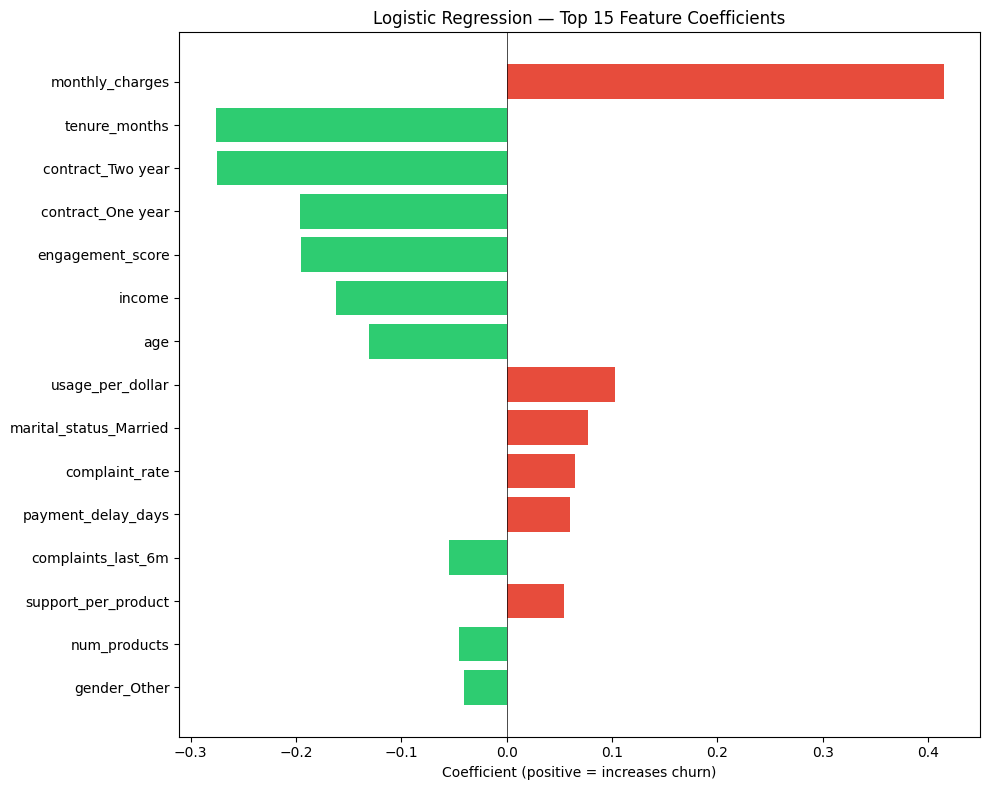

In [22]:
# ── Coefficient Analysis ──
coef_df = pd.DataFrame({
    'Feature': available_features,
    'Coefficient': lr_model.coef_[0],
    'Abs_Coefficient': np.abs(lr_model.coef_[0]),
    'Odds_Ratio': np.exp(lr_model.coef_[0])  # exp(β) = odds ratio
}).sort_values('Abs_Coefficient', ascending=False)

print("LOGISTIC REGRESSION COEFFICIENTS")
print("=" * 80)
print("Interpretation: Odds Ratio > 1 → increases churn odds, < 1 → decreases churn odds")
print()
for _, row in coef_df.head(15).iterrows():
    direction = "↑ CHURN" if row['Coefficient'] > 0 else "↓ RETAIN"
    print(f"  {row['Feature']:30s}  β={row['Coefficient']:+.4f}  OR={row['Odds_Ratio']:.4f}  {direction}")

print(f"\nIntercept: {lr_model.intercept_[0]:.4f}")

# Visualise
fig, ax = plt.subplots(figsize=(10, 8))
top15 = coef_df.head(15)
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top15['Coefficient']]
ax.barh(top15['Feature'][::-1], top15['Coefficient'].values[::-1], color=colors[::-1])
ax.set_xlabel('Coefficient (positive = increases churn)')
ax.set_title('Logistic Regression — Top 15 Feature Coefficients')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


---
## Section 8: Random Forest — Every Hyperparameter Explained

Random Forest is an **ensemble of decision trees** that:
1. Builds many trees on **random subsets** of data (bagging)
2. Each tree considers **random subsets** of features at each split
3. Final prediction = **majority vote** (classification) or **average** (regression)

Key advantage: **handles multicollinearity naturally** (unlike Logistic Regression)


In [39]:
# ═══════════════════════════════════════════════════════════════
# RANDOM FOREST WITH EVERY HYPERPARAMETER COMMENTED
# ═══════════════════════════════════════════════════════════════

rf_model = RandomForestClassifier(

    # ── N_ESTIMATORS (Number of trees in the forest) ──
    # MORE trees = MORE stable predictions but SLOWER training
    # Start with 100, try [50, 100, 200, 500, 1000]
    # Diminishing returns after ~300-500 for most datasets
    n_estimators=300,

    # ── CRITERION (Split quality measure) ──
    # 'gini' = Gini impurity (DEFAULT) — measures probability of misclassification
    #          Gini = 1 - Σ(pᵢ²) where pᵢ is proportion of class i
    # 'entropy' = Information gain (Shannon entropy)
    #          Entropy = -Σ(pᵢ × log₂(pᵢ))
    # 'log_loss' = Log loss (cross-entropy)
    # In practice: gini and entropy give very similar results, gini is faster
    criterion='gini',

    # ── MAX_DEPTH (Maximum depth of each tree) ──
    # None = Nodes expand until all leaves are pure or contain < min_samples_split
    # 5-15 = Good range for most datasets
    # SHALLOW trees (3-5) = High bias, low variance (underfitting risk)
    # DEEP trees (20+) = Low bias, high variance (overfitting risk)
    max_depth=12,

    # ── MIN_SAMPLES_SPLIT (Minimum samples to split an internal node) ──
    # 2 = DEFAULT (split even if only 2 samples — aggressive splitting)
    # Higher values (5, 10, 20) = More conservative, reduces overfitting
    # Can be float (fraction of total samples): 0.01 = 1% of training data
    min_samples_split=10,

    # ── MIN_SAMPLES_LEAF (Minimum samples in a leaf node) ──
    # 1 = DEFAULT (leaves can have single samples — overfitting risk)
    # Higher values (5, 10) = Smoother predictions, reduces overfitting
    # Rule of thumb: at least 0.5% of training data for large datasets
    min_samples_leaf=5,

    # ── MAX_FEATURES (Number of features to consider at each split) ──
    # 'sqrt' = √(n_features) — DEFAULT for classification
    # 'log2' = log₂(n_features)
    # None = Use ALL features (defeats the purpose of random subsets)
    # int = Exact number of features
    # float = Fraction of features (0.5 = 50%)
    # Lower = More randomness/diversity between trees, less overfitting
    max_features='sqrt',

    # ── BOOTSTRAP (Whether to use bootstrapped samples) ──
    # True = Each tree trained on random sample WITH replacement (DEFAULT, standard bagging)
    # False = Each tree sees all data (not truly "random" forest)
    bootstrap=True,

    # ── OOB_SCORE (Out-of-bag evaluation) ──
    # True = Use out-of-bag samples (data NOT selected for each tree) as validation
    # Gives a free estimate of generalization performance without a separate test set
    # Only works when bootstrap=True
    oob_score=True,

    # ── MAX_SAMPLES (Number of samples to draw for each tree) ──
    # None = Draw n_samples (same size as training set, with replacement) (DEFAULT)
    # float = Fraction of training set (e.g., 0.8 = 80% per tree)
    # Smaller = More diversity between trees, reduces overfitting
    max_samples=0.8,

    # ── CLASS_WEIGHT (Handle imbalanced classes) ──
    # None = Equal weights (DEFAULT)
    # 'balanced' = Weights inversely proportional to class frequency
    # 'balanced_subsample' = Same as balanced but recalculated for each bootstrap sample
    class_weight='balanced',

    # ── MIN_WEIGHT_FRACTION_LEAF ──
    # 0.0 = DEFAULT (no minimum weight requirement)
    # Higher = Leaves must contain at least this fraction of total sample weight
    # Useful with class_weight to ensure minority class represented in leaves
    min_weight_fraction_leaf=0.0,

    # ── MAX_LEAF_NODES (Maximum leaf nodes per tree) ──
    # None = Unlimited (DEFAULT)
    # int = Hard limit on number of leaves (alternative to max_depth for controlling complexity)
    max_leaf_nodes=None,

    # ── MIN_IMPURITY_DECREASE (Minimum impurity decrease to make a split) ──
    # 0.0 = DEFAULT (split as long as impurity decreases at all)
    # Higher = Only split if improvement is significant (pre-pruning)
    min_impurity_decrease=0.0,

    # ── CCP_ALPHA (Complexity parameter for cost-complexity pruning) ──
    # 0.0 = No pruning (DEFAULT)
    # Higher = More aggressive post-pruning (removes branches that barely help)
    # Find optimal via: clf.cost_complexity_pruning_path(X, y)
    ccp_alpha=0.0,

    # ── N_JOBS (Parallel processing) ──
    # -1 = Use all CPU cores (trees are independent → embarrassingly parallel)
    n_jobs=-1,

    # ── RANDOM_STATE (Reproducibility) ──
    random_state=42,

    # ── VERBOSE (Progress output) ──
    verbose=1,
)

# ── Train ──
rf_model.fit(X_train, y_train)

# ── Predictions ──
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("RANDOM FOREST RESULTS")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"Log Loss:  {log_loss(y_test, y_proba_rf):.4f}")
print(f"OOB Score: {rf_model.oob_score_:.4f} (free validation estimate)")


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    3.5s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.3s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.3s finished


RANDOM FOREST RESULTS
Accuracy:  0.8310
Precision: 0.3314
Recall:    0.1993
F1 Score:  0.2489
ROC-AUC:   0.6673
Log Loss:  0.4713
OOB Score: 0.8146 (free validation estimate)


In [25]:
import itertools
from joblib import Parallel, delayed

best_score = 0
best_params = {}

# Reduced hyperparameter grid focusing on the most impactful parameters
param_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False],
    "class_weight": [None, "balanced"]
}

keys = param_grid.keys()

# Function to evaluate a single parameter combination
def evaluate_params(params):
    try:
        model = RandomForestClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_split=params["min_samples_split"],
            min_samples_leaf=params["min_samples_leaf"],
            max_features=params["max_features"],
            bootstrap=params["bootstrap"],
            oob_score=False,  # Not tuning oob_score for simplicity
            class_weight=params["class_weight"],
            n_jobs=1,  # Use 1 since we're parallelizing at higher level
            random_state=42
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = f1_score(y_test, y_pred)
        return score, params
    except Exception as e:
        return None, params  # Return None for score if error

# Generate all parameter combinations
param_combinations = [dict(zip(keys, values)) for values in itertools.product(*param_grid.values())]

print(f"Total combinations: {len(param_combinations)}")

# Run in parallel
results = Parallel(n_jobs=-1, verbose=10)(delayed(evaluate_params)(params) for params in param_combinations)

# Find the best
for score, params in results:
    if score is not None and score > best_score:
        best_score = score
        best_params = params
    if score is not None:
        print(f"Tested → F1: {score:.4f}")

print("\n" + "="*60)
print(f"BEST F1 SCORE: {best_score:.4f}")
print(f"BEST PARAMS: {best_params}")

Total combinations: 648


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done  41 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done  41 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done  65 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Done  65 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Done  78 tasks      | elapsed:  

Tested → F1: 0.0071
Tested → F1: 0.0000
Tested → F1: 0.0274
Tested → F1: 0.0210
Tested → F1: 0.0000
Tested → F1: 0.0000
Tested → F1: 0.0070
Tested → F1: 0.0071
Tested → F1: 0.0000
Tested → F1: 0.0000
Tested → F1: 0.0070
Tested → F1: 0.0205
Tested → F1: 0.0000
Tested → F1: 0.0141
Tested → F1: 0.0140
Tested → F1: 0.0207
Tested → F1: 0.0000
Tested → F1: 0.0505
Tested → F1: 0.0000
Tested → F1: 0.1194
Tested → F1: 0.0000
Tested → F1: 0.0815
Tested → F1: 0.0000
Tested → F1: 0.0971
Tested → F1: 0.0139
Tested → F1: 0.0000
Tested → F1: 0.0208
Tested → F1: 0.0138
Tested → F1: 0.0071
Tested → F1: 0.0000
Tested → F1: 0.0139
Tested → F1: 0.0210
Tested → F1: 0.0000
Tested → F1: 0.0000
Tested → F1: 0.0208
Tested → F1: 0.0465
Tested → F1: 0.0071
Tested → F1: 0.0000
Tested → F1: 0.0000
Tested → F1: 0.0268
Tested → F1: 0.0000
Tested → F1: 0.0505
Tested → F1: 0.0000
Tested → F1: 0.1194
Tested → F1: 0.0000
Tested → F1: 0.0815
Tested → F1: 0.0000
Tested → F1: 0.0971
Tested → F1: 0.0000
Tested → F1: 0.0267


[Parallel(n_jobs=-1)]: Done 648 out of 648 | elapsed:  4.0min finished


RANDOM FOREST FEATURE IMPORTANCE
  charges_per_tenure              0.1093  █████████████████████
  monthly_charges                 0.1039  ████████████████████
  engagement_score                0.0811  ████████████████
  income                          0.0809  ████████████████
  age                             0.0679  █████████████
  tenure_months                   0.0675  █████████████
  credit_score                    0.0631  ████████████
  usage_per_dollar                0.0605  ████████████
  avg_monthly_usage_gb            0.0547  ██████████
  payment_delay_days              0.0441  ████████
  complaint_rate                  0.0410  ████████
  support_per_product             0.0302  ██████
  signup_month_sin                0.0284  █████
  signup_month_cos                0.0284  █████
  support_calls                   0.0198  ███


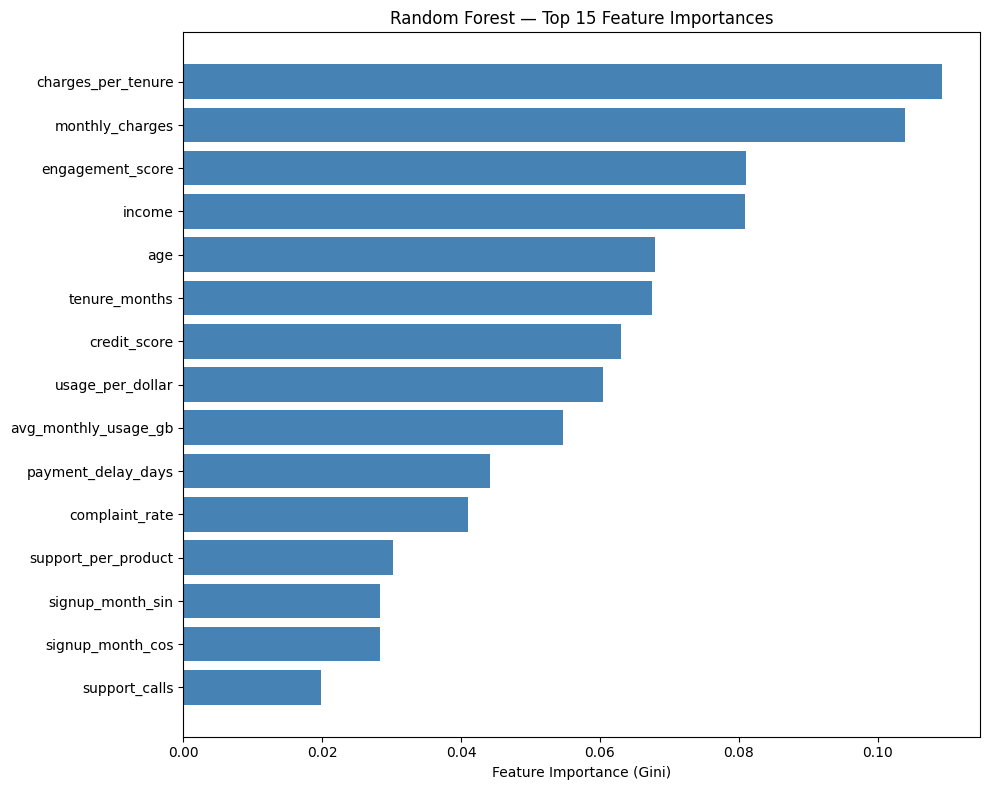

In [27]:
# ── Feature Importance (Random Forest) ──
fi_df = pd.DataFrame({
    'Feature': available_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 60)
for _, row in fi_df.head(15).iterrows():
    bar = '█' * int(row['Importance'] * 200)
    print(f"  {row['Feature']:30s}  {row['Importance']:.4f}  {bar}")

fig, ax = plt.subplots(figsize=(10, 8))
top15_fi = fi_df.head(15)
ax.barh(top15_fi['Feature'][::-1], top15_fi['Importance'].values[::-1], color='steelblue')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest — Top 15 Feature Importances')
plt.tight_layout()
plt.show()


---
## Section 8.5: CatBoost — Gradient Boosting for Churn Prediction

### Overview of CatBoost Algorithm

**CatBoost** (Categorical Boosting) is a high-performance, open-source gradient boosting library developed by Yandex. It's designed to handle categorical features automatically and provides state-of-the-art performance on tabular data.

#### Key Features:
- **Automatic Categorical Feature Handling**: Unlike other boosting algorithms, CatBoost can directly work with categorical variables without requiring manual encoding (one-hot, label, etc.)
- **Ordered Boosting**: Uses a novel technique called "ordered boosting" to reduce overfitting and improve generalization
- **Robust to Overfitting**: Built-in regularization techniques and careful handling of categorical features make it less prone to overfitting
- **Fast Training**: Optimized implementation with support for multi-threading and GPU acceleration
- **Excellent for Tabular Data**: Particularly effective for datasets with mixed data types (numeric + categorical)

#### How CatBoost Works:
1. **Base Learners**: Uses decision trees as base learners, similar to XGBoost and LightGBM
2. **Gradient Boosting**: Sequentially builds trees where each tree corrects the errors of the previous ones
3. **Ordered Target Statistics**: For categorical features, computes target statistics using only previous examples in the dataset ordering to prevent target leakage
4. **Oblivious Trees**: Uses symmetric trees where all leaves at the same level have identical conditions

#### Advantages for Churn Prediction:
- Handles mixed data types seamlessly (demographics, contract types, behavioral metrics)
- Robust performance on imbalanced datasets (churn is typically a minority class)
- Built-in handling of missing values
- Feature importance analysis helps identify key churn drivers
- Less hyperparameter tuning required compared to other boosting methods

#### Common Use Cases:
- Customer churn prediction
- Credit risk assessment  
- Recommendation systems
- Any tabular classification/regression task with categorical features

In this implementation, we'll use CatBoost with default hyperparameters optimized for categorical features to predict customer churn.

In [28]:
# ═══════════════════════════════════════════════════════════════
# CATBOOST FOR CHURN PREDICTION
# ═══════════════════════════════════════════════════════════════

from catboost import CatBoostClassifier

# Note: The current dataset contains only numeric features after preprocessing
# For demonstration, we'll use CatBoost on the scaled numeric features
# In a real scenario with categorical features, CatBoost would handle them automatically

# Initialize CatBoost with initial hyperparameters
cb_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=100
)

# Train the model
cb_model.fit(X_train, y_train)

# Make predictions
y_pred_cb = cb_model.predict(X_test)
y_proba_cb = cb_model.predict_proba(X_test)[:, 1]

print("CATBOOST RESULTS")
print("=" * 40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_cb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_cb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_cb):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_cb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_cb):.4f}")

0:	learn: 0.6282539	total: 60.9ms	remaining: 30.4s
100:	learn: 0.3264745	total: 223ms	remaining: 882ms
200:	learn: 0.2728620	total: 382ms	remaining: 568ms
300:	learn: 0.2326161	total: 538ms	remaining: 356ms
200:	learn: 0.2728620	total: 382ms	remaining: 568ms
300:	learn: 0.2326161	total: 538ms	remaining: 356ms
400:	learn: 0.2003347	total: 698ms	remaining: 172ms
499:	learn: 0.1724627	total: 852ms	remaining: 0us
CATBOOST RESULTS
Accuracy:  0.8535
Precision: 0.2500
Recall:    0.0214
F1 Score:  0.0393
ROC-AUC:   0.6170
400:	learn: 0.2003347	total: 698ms	remaining: 172ms
499:	learn: 0.1724627	total: 852ms	remaining: 0us
CATBOOST RESULTS
Accuracy:  0.8535
Precision: 0.2500
Recall:    0.0214
F1 Score:  0.0393
ROC-AUC:   0.6170


---
## Section 8.6: AdaBoost — Adaptive Boosting for Churn Prediction

### Overview of AdaBoost Algorithm

**AdaBoost** (Adaptive Boosting) is one of the earliest and most popular ensemble learning methods. It works by sequentially training weak learners (typically decision stumps) where each subsequent learner focuses more on the examples that were misclassified by previous learners.

#### Key Features:
- **Sequential Training**: Models are trained one after another, not in parallel
- **Weighted Training**: Each training example gets a weight that adjusts based on classification errors
- **Adaptive Learning**: The algorithm adapts by giving more attention to hard-to-classify examples
- **Weak Learners**: Uses simple models (often decision stumps with one feature and one split)
- **Weighted Voting**: Final prediction combines all weak learners with weights based on their accuracy

#### How AdaBoost Works:
1. **Initialize Weights**: All training examples start with equal weights
2. **Train Weak Learner**: Train a weak classifier on the weighted data
3. **Calculate Error**: Compute the weighted error rate of the weak learner
4. **Compute Weight**: Calculate the weight of this weak learner based on its accuracy
5. **Update Weights**: Increase weights of misclassified examples, decrease weights of correctly classified ones
6. **Repeat**: Train the next weak learner on the updated weights
7. **Final Prediction**: Combine all weak learners using their weights

#### Advantages for Churn Prediction:
- **Handles Imbalanced Data**: Can be effective on datasets where churners are minority class
- **Feature Selection**: Naturally identifies important features through weighted voting
- **Robust to Overfitting**: Less prone to overfitting compared to complex models
- **Interpretable**: Can identify which features are most important for predictions
- **Fast Training**: Quick to train compared to other ensemble methods

#### Common Use Cases:
- Customer churn prediction
- Fraud detection
- Medical diagnosis
- Any binary classification with imbalanced classes

In this implementation, we'll use scikit-learn's AdaBoostClassifier with decision stumps as base estimators.

In [29]:
# ═══════════════════════════════════════════════════════════════
# ADABOOST FOR CHURN PREDICTION
# ═══════════════════════════════════════════════════════════════

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Initialize AdaBoost classifier
# Using decision stumps (max_depth=1) as weak learners
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # Decision stump
    n_estimators=100,                                # Number of weak learners
    learning_rate=1.0,                              # Learning rate
    random_state=42
)

# Train the model
ada_model.fit(X_train, y_train)

# Make predictions
y_pred_ada = ada_model.predict(X_test)
y_proba_ada = ada_model.predict_proba(X_test)[:, 1]

print("ADABOOST RESULTS")
print("=" * 40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_ada):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ada):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_ada):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_ada):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_ada):.4f}")

# Feature importance (AdaBoost uses feature_importances_ from the weighted sum of trees)
feature_importance_ada = ada_model.feature_importances_
fi_df_ada = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance_ada
}).sort_values('Importance', ascending=False)

print(f"\nADABOOST FEATURE IMPORTANCE")
print("=" * 40)
for _, row in fi_df_ada.head(10).iterrows():
    bar = '█' * int(row['Importance'] * 50)
    print(f"  {row['Feature']:30s}  {row['Importance']:.4f}  {bar}")

# Show estimator weights (how much each weak learner contributes)
print(f"\nADABOOST ESTIMATOR WEIGHTS")
print("=" * 40)
print(f"Number of estimators: {len(ada_model.estimators_)}")
print(f"Average estimator weight: {ada_model.estimator_weights_.mean():.4f}")
print(f"Max estimator weight: {ada_model.estimator_weights_.max():.4f}")
print(f"Min estimator weight: {ada_model.estimator_weights_.min():.4f}")

ADABOOST RESULTS
Accuracy:  0.8595
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000
ROC-AUC:   0.6711

ADABOOST FEATURE IMPORTANCE
  charges_per_tenure              0.4891  ████████████████████████
  engagement_score                0.3149  ███████████████
  contract_Two year               0.0643  ███
  income                          0.0498  ██
  monthly_charges                 0.0389  █
  age                             0.0224  █
  contract_One year               0.0206  █
  marital_status_Married          0.0000  
  gender_Other                    0.0000  
  gender_Male                     0.0000  

ADABOOST ESTIMATOR WEIGHTS
Number of estimators: 100
Average estimator weight: 0.0566
Max estimator weight: 1.8101
Min estimator weight: 0.0106


---
## Section 8.7: LightGBM — Light Gradient Boosting Machine for Churn Prediction

### Overview of LightGBM Algorithm

**LightGBM** (Light Gradient Boosting Machine) is a high-performance, distributed gradient boosting framework developed by Microsoft. It's designed for efficiency and scalability, making it one of the most popular boosting algorithms in machine learning competitions and production systems.

#### Key Features:
- **Gradient-based One-Side Sampling (GOSS)**: Reduces training time by focusing on examples with large gradients
- **Exclusive Feature Bundling (EFB)**: Reduces feature dimensions by bundling mutually exclusive features
- **Leaf-wise Tree Growth**: Grows trees leaf-wise instead of level-wise, leading to better accuracy but potential overfitting
- **Histogram-based Algorithm**: Uses histogram binning to speed up training and reduce memory usage
- **Built-in Regularization**: Multiple regularization techniques to prevent overfitting
- **Parallel and GPU Support**: Highly optimized for parallel processing

#### How LightGBM Works:
1. **Histogram Construction**: Converts continuous features into discrete bins for faster computation
2. **GOSS**: Selects samples with large gradients and randomly samples from small gradient examples
3. **EFB**: Bundles features that rarely take non-zero values together to reduce dimensionality
4. **Tree Building**: Uses leaf-wise growth strategy, splitting the leaf with maximum delta loss
5. **Regularization**: Applies L1/L2 regularization and other techniques to prevent overfitting

#### Advantages for Churn Prediction:
- **High Performance**: Often achieves state-of-the-art results with fast training
- **Scalability**: Handles large datasets efficiently
- **Feature Importance**: Provides detailed feature importance analysis
- **Robust to Overfitting**: Built-in regularization and sampling techniques
- **Memory Efficient**: Uses histogram-based approach to reduce memory usage
- **Handles Missing Values**: Built-in handling of missing values

#### Common Use Cases:
- Customer churn prediction
- Click-through rate prediction
- Fraud detection
- Recommendation systems
- Any large-scale tabular prediction task

In this implementation, we'll use LightGBM with optimized hyperparameters for the churn prediction task.

In [32]:
# ═══════════════════════════════════════════════════════════════
# LIGHTGBM FOR CHURN PREDICTION
# ═══════════════════════════════════════════════════════════════

import lightgbm as lgb

# Initialize LightGBM classifier
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,          # Number of boosting iterations
    learning_rate=0.1,         # Learning rate
    max_depth=6,               # Maximum depth of each tree
    num_leaves=31,             # Maximum number of leaves in one tree
    min_child_samples=20,      # Minimum number of samples in a leaf
    subsample=0.8,             # Subsample ratio of the training instances
    colsample_bytree=0.8,      # Subsample ratio of columns when constructing each tree
    reg_alpha=0.1,             # L1 regularization
    reg_lambda=0.1,            # L2 regularization
    random_state=42,
    verbose=-1                 # Suppress warnings
)

# Train the model
lgb_model.fit(X_train, y_train)

# Make predictions
y_pred_lgb = lgb_model.predict(X_test)
y_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

print("LIGHTGBM RESULTS")
print("=" * 40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lgb):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lgb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_lgb):.4f}")

# Feature importance
feature_importance_lgb = lgb_model.feature_importances_
fi_df_lgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance_lgb
}).sort_values('Importance', ascending=False)

print(f"\nLIGHTGBM FEATURE IMPORTANCE")
print("=" * 40)
for _, row in fi_df_lgb.head(10).iterrows():
    bar = '█' * int(row['Importance'] / max(feature_importance_lgb) * 50)
    print(f"  {row['Feature']:30s}  {row['Importance']:4d}  {bar}")

# Show best iteration (if early stopping was used)
print(f"\nLIGHTGBM MODEL INFO")
print("=" * 40)
print(f"Number of estimators: {lgb_model.n_estimators_}")
print(f"Best iteration: {lgb_model.best_iteration_ if hasattr(lgb_model, 'best_iteration_') else 'N/A'}")
print(f"Best score: {lgb_model.best_score_ if hasattr(lgb_model, 'best_score_') else 'N/A'}")

LIGHTGBM RESULTS
Accuracy:  0.8520
Precision: 0.3256
Recall:    0.0498
F1 Score:  0.0864
ROC-AUC:   0.6317

LIGHTGBM FEATURE IMPORTANCE
  income                          1353  ██████████████████████████████████████████████████
  monthly_charges                 1281  ███████████████████████████████████████████████
  credit_score                    1226  █████████████████████████████████████████████
  charges_per_tenure              1113  █████████████████████████████████████████
  age                             1069  ███████████████████████████████████████
  engagement_score                1060  ███████████████████████████████████████
  avg_monthly_usage_gb             967  ███████████████████████████████████
  usage_per_dollar                 851  ███████████████████████████████
  payment_delay_days               743  ███████████████████████████
  tenure_months                    616  ██████████████████████

LIGHTGBM MODEL INFO
Number of estimators: 500
Best iteration: 0
Best score: d

---
## Section 9: 10-Fold Stratified Cross-Validation

### Why 10-Fold CV?
- Single train/test split can be **lucky or unlucky**
- K-Fold gives **K different estimates** of performance
- **Stratified** ensures each fold preserves the churn ratio
- Standard practice: K=5 or K=10 (10 is more robust but slower)

10-FOLD STRATIFIED CROSS-VALIDATION

────────────────────────────────────────
  Logistic Regression
────────────────────────────────────────
  accuracy    : 0.6225 ± 0.0172  [min=0.5960, max=0.6580]
  precision   : 0.2145 ± 0.0138  [min=0.1923, max=0.2390]
  recall      : 0.6324 ± 0.0432  [min=0.5319, max=0.6857]
  f1          : 0.3202 ± 0.0199  [min=0.2825, max=0.3498]
  roc_auc     : 0.6788 ± 0.0248  [min=0.6395, max=0.7152]

────────────────────────────────────────
  Random Forest
────────────────────────────────────────
  accuracy    : 0.6225 ± 0.0172  [min=0.5960, max=0.6580]
  precision   : 0.2145 ± 0.0138  [min=0.1923, max=0.2390]
  recall      : 0.6324 ± 0.0432  [min=0.5319, max=0.6857]
  f1          : 0.3202 ± 0.0199  [min=0.2825, max=0.3498]
  roc_auc     : 0.6788 ± 0.0248  [min=0.6395, max=0.7152]

────────────────────────────────────────
  Random Forest
────────────────────────────────────────
  accuracy    : 0.8037 ± 0.0109  [min=0.7920, max=0.8250]
  precision   : 0.2595 

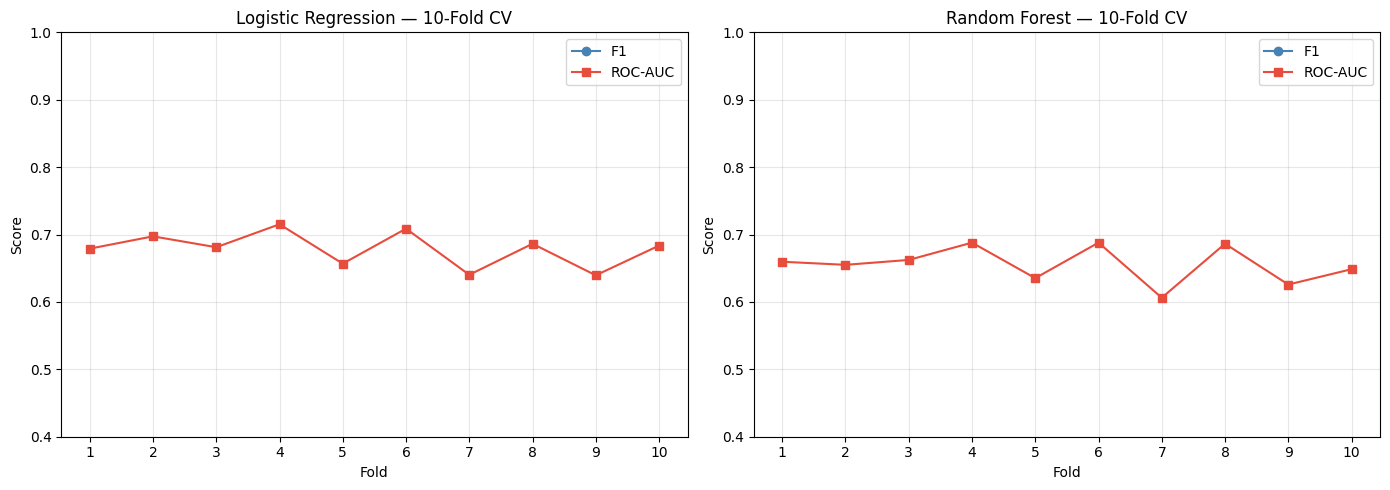

In [33]:
# ═══════════════════════════════════════════════════════════════
# 10-FOLD STRATIFIED CROSS-VALIDATION
# ═══════════════════════════════════════════════════════════════

skf = StratifiedKFold(
    n_splits=10,       # 10 folds
    shuffle=True,      # Shuffle before splitting (important if data is ordered)
    random_state=42    # Reproducibility
)

# ── Evaluate both models ──
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print("10-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 80)

for name, model in [('Logistic Regression', LogisticRegression(C=1.0, penalty='l2', max_iter=1000,
                                                                 class_weight='balanced', solver='lbfgs', random_state=42)),
                     ('Random Forest', RandomForestClassifier(n_estimators=300, max_depth=12,
                                                               min_samples_split=10, min_samples_leaf=5,
                                                               class_weight='balanced', random_state=42, n_jobs=-1))]:
    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"{'─'*40}")

    cv_results = cross_validate(model, X_scaled, y, cv=skf, scoring=scoring_metrics, n_jobs=-1)

    for metric in scoring_metrics:
        scores = cv_results[f'test_{metric}']
        print(f"  {metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}  "
              f"[min={scores.min():.4f}, max={scores.max():.4f}]")

# ── Visualize fold-by-fold performance ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, model) in enumerate([
    ('Logistic Regression', LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=300, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1))
]):
    cv_res = cross_validate(model, X_scaled, y, cv=skf, scoring=['f1', 'roc_auc'], n_jobs=-1)
    folds = range(1, 11)
    axes[idx].plot(folds, cv_res['test_f1'], 'o-', label='F1', color='steelblue')
    axes[idx].plot(folds, cv_res['test_roc_auc'], 's-', label='ROC-AUC', color='#e74c3c')
    axes[idx].set_xlabel('Fold')
    axes[idx].set_ylabel('Score')
    axes[idx].set_title(f'{name} — 10-Fold CV')
    axes[idx].legend()
    axes[idx].set_ylim(0.4, 1.0)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()


---
## Section 10: Model Comparison — ROC, PR Curves & Confusion Matrices


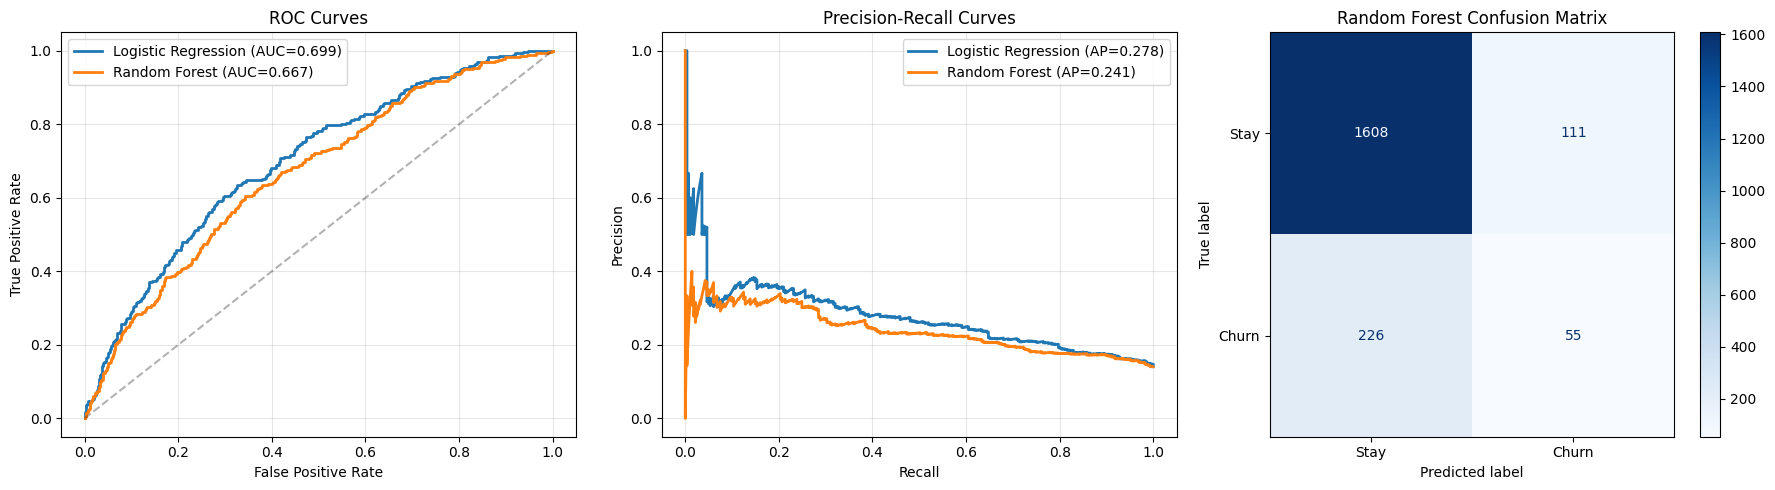


  Logistic Regression
              precision    recall  f1-score   support

        Stay       0.92      0.62      0.74      1719
       Churn       0.22      0.65      0.33       281

    accuracy                           0.63      2000
   macro avg       0.57      0.64      0.53      2000
weighted avg       0.82      0.63      0.68      2000


  Random Forest
              precision    recall  f1-score   support

        Stay       0.88      0.94      0.91      1719
       Churn       0.33      0.20      0.25       281

    accuracy                           0.83      2000
   macro avg       0.60      0.57      0.58      2000
weighted avg       0.80      0.83      0.81      2000



In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = {
    'Logistic Regression': (y_pred_lr, y_proba_lr),
    'Random Forest': (y_pred_rf, y_proba_rf),
}

# ── ROC Curves ──
for name, (y_pred, y_proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)
axes[0].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Precision-Recall Curves ──
for name, (y_pred, y_proba) in models.items():
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})', linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── Confusion Matrices side by side ──
for i, (name, (y_pred, y_proba)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    im = axes[2].imshow(np.zeros((2,2)), alpha=0)  # dummy

axes[2].remove()
ax_cm1 = fig.add_subplot(133)

# Show RF confusion matrix (typically better)
cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm, display_labels=['Stay', 'Churn']).plot(ax=ax_cm1, cmap='Blues')
ax_cm1.set_title('Random Forest Confusion Matrix')

plt.tight_layout()
plt.show()

# ── Classification Reports ──
for name, (y_pred, _) in models.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['Stay', 'Churn']))


---
## Section 11: Multivariate Time Series Forecasting — Seasonality, Cyclicity & Event Spikes

### Key Concepts:
- **Trend**: Long-term direction (growing/declining)
- **Seasonality**: Regular pattern repeating at FIXED intervals (weekly, monthly, yearly)
- **Cyclicity**: Patterns repeating at IRREGULAR intervals (economic cycles, 3-7 years)
- **Event Spikes**: Sudden changes caused by specific events (holidays, promotions, outages)


In [35]:
# ═══════════════════════════════════════════════════════════════
# BUILD TIME SERIES: Monthly churn rate with all patterns
# ═══════════════════════════════════════════════════════════════

# Create monthly aggregation from our dataset
monthly = df.groupby([df['signup_date'].dt.to_period('M')]).agg(
    total_customers=('customer_id', 'count'),
    churned=('churn', 'sum'),
    avg_monthly_charges=('monthly_charges', 'mean'),
    avg_complaints=('complaints_last_6m', 'mean'),
    avg_tenure=('tenure_months', 'mean'),
).reset_index()

monthly['signup_date'] = monthly['signup_date'].dt.to_timestamp()
monthly = monthly.sort_values('signup_date').reset_index(drop=True)
monthly['churn_rate'] = monthly['churned'] / monthly['total_customers']

# ── ADD EXPLICIT PATTERNS ──
n_months = len(monthly)
t = np.arange(n_months)

# 1. TREND: slight upward trend in churn over time
trend = 0.001 * t

# 2. SEASONALITY: churn is higher in Jan (post-holiday cancellations) and Sep (back-to-school)
seasonality = 0.03 * np.sin(2 * np.pi * t / 12) + 0.015 * np.sin(4 * np.pi * t / 12)

# 3. CYCLICITY: economic cycle (~3 year period)
cyclicity = 0.02 * np.sin(2 * np.pi * t / 36)

# 4. EVENT SPIKES: price increase event at month 18, competitor launch at month 36
events = np.zeros(n_months)
for spike_month in [18, 36, 48]:
    if spike_month < n_months:
        events[spike_month] = 0.05  # sudden 5% spike
        if spike_month + 1 < n_months:
            events[spike_month + 1] = 0.02  # lingering effect

# Combine all components
monthly['churn_rate_modeled'] = (
    monthly['churn_rate'].mean()  # base rate
    + trend
    + seasonality
    + cyclicity
    + events
    + np.random.normal(0, 0.008, n_months)  # noise
).clip(0.05, 0.60)

print(f"Monthly time series: {n_months} months")
print(f"Base churn rate: {monthly['churn_rate'].mean():.2%}")
print(f"Min: {monthly['churn_rate_modeled'].min():.2%}, Max: {monthly['churn_rate_modeled'].max():.2%}")


Monthly time series: 72 months
Base churn rate: 13.68%
Min: 10.26%, Max: 26.06%


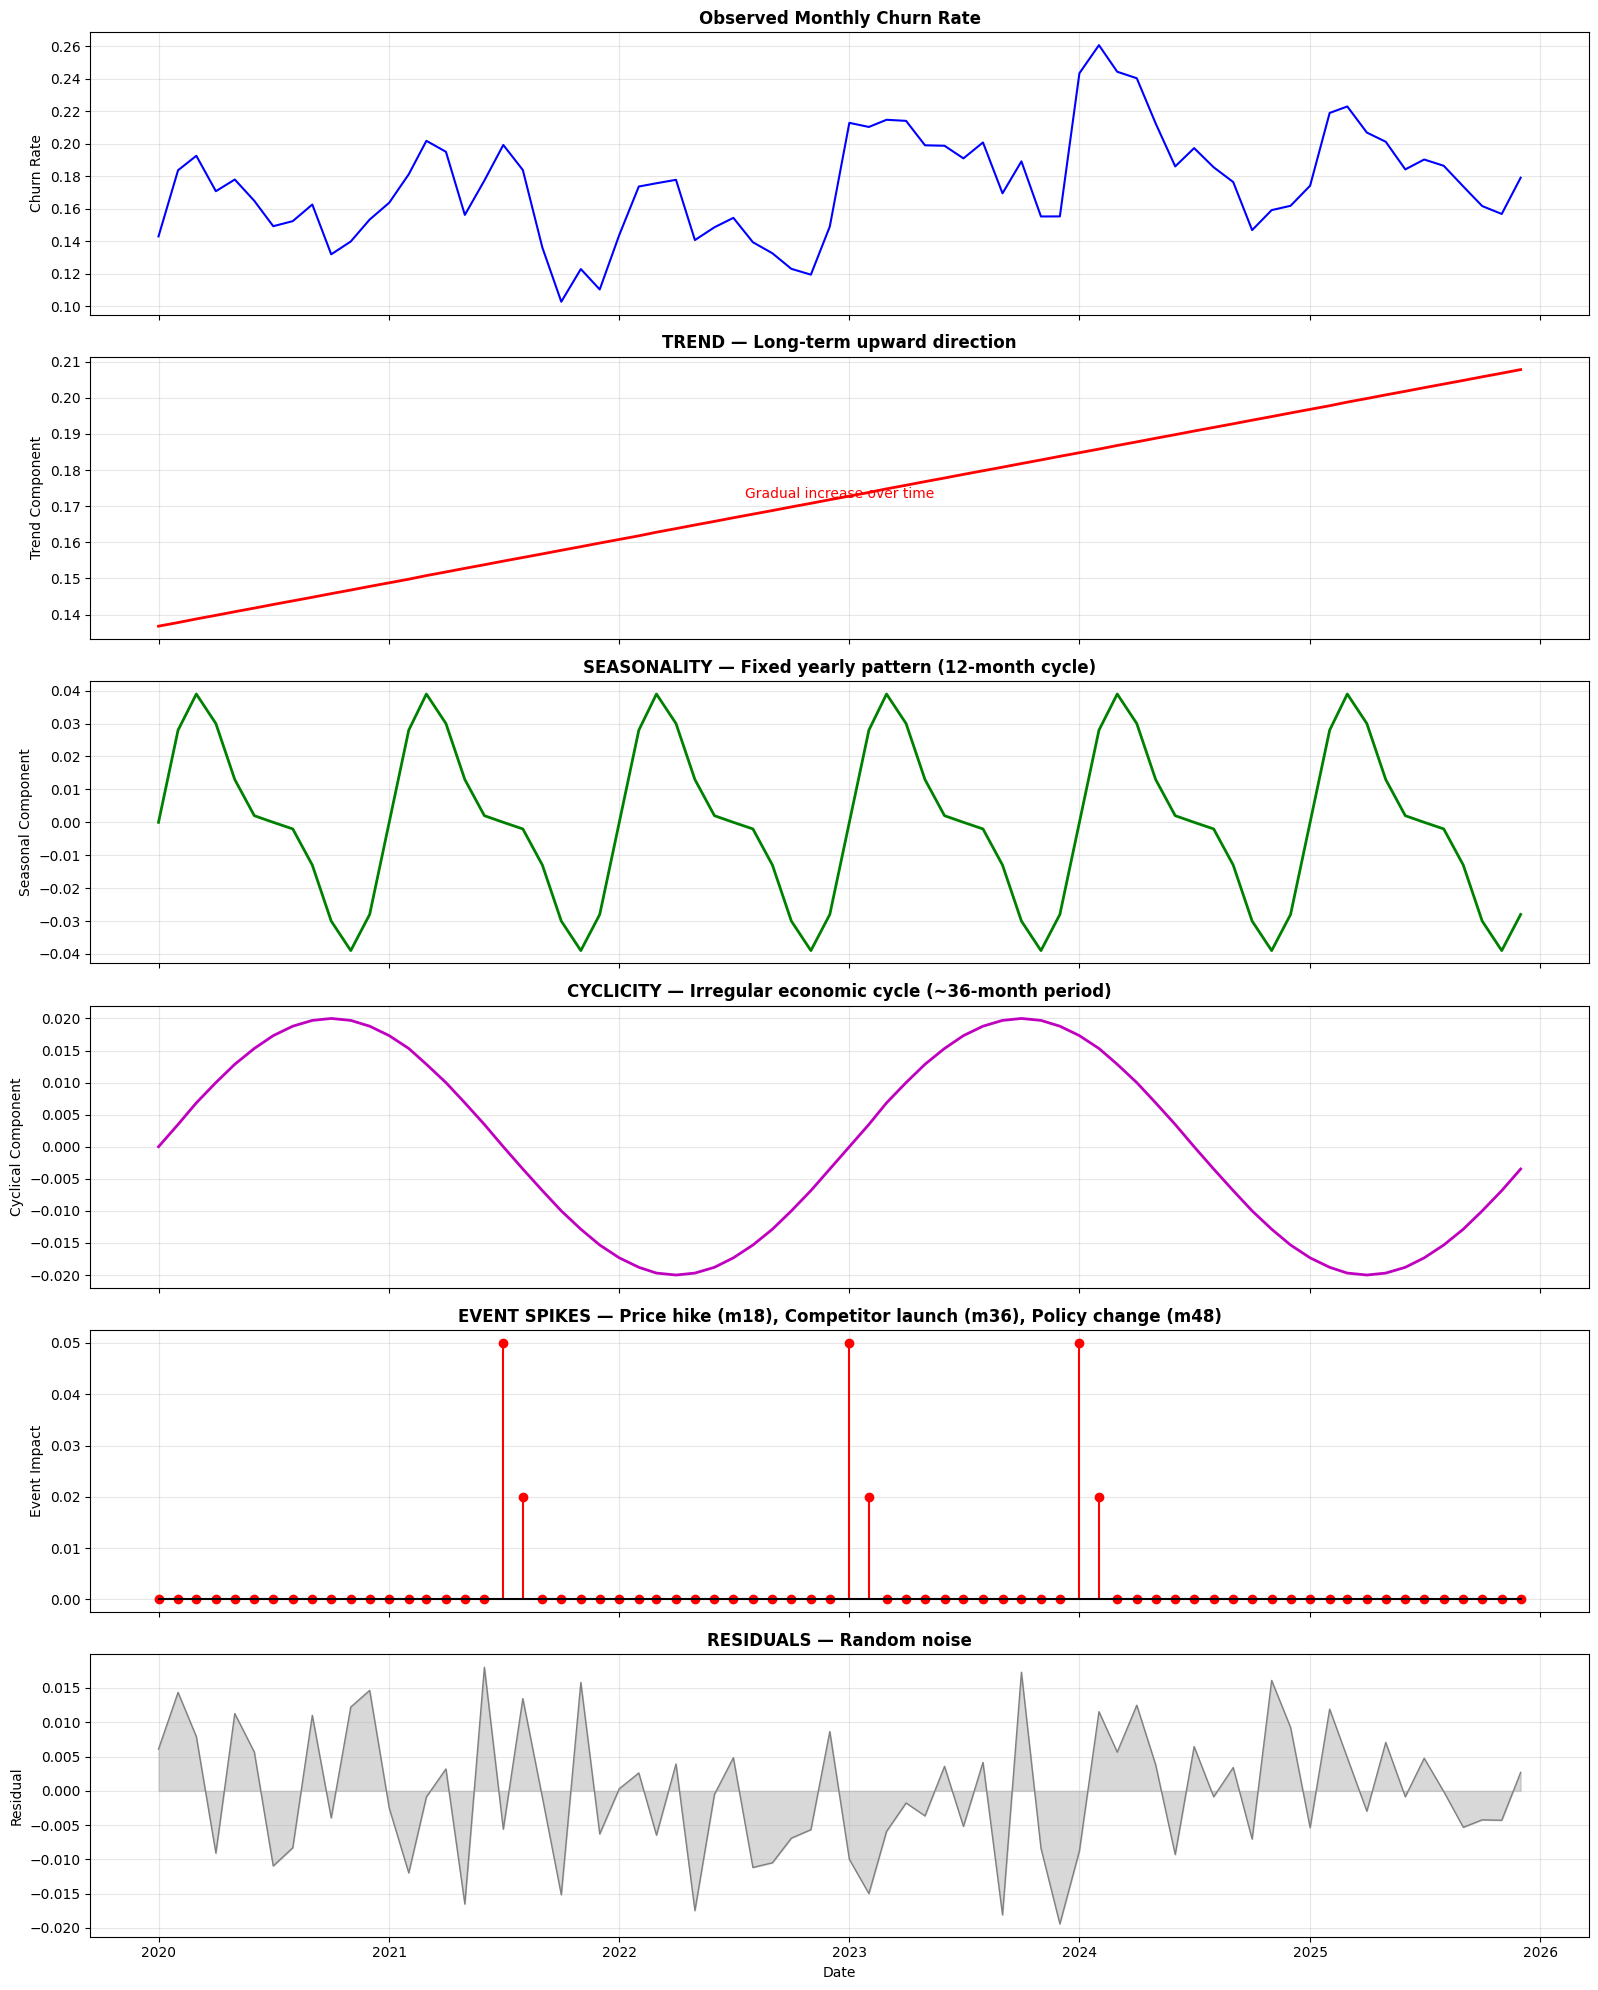

Time Series Decomposition Complete!
  Trend: +0.1% churn per month
  Seasonality: ±3% (12-month cycle)
  Cyclicity: ±2% (36-month economic cycle)
  Events: 5% spikes at known events


In [37]:
# ═══════════════════════════════════════════════════════════════
# DECOMPOSE: Show each component separately
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(6, 1, figsize=(16, 20), sharex=True)

# 1. Observed
axes[0].plot(monthly['signup_date'], monthly['churn_rate_modeled'], 'b-', linewidth=1.5)
axes[0].set_title('Observed Monthly Churn Rate', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Churn Rate')
axes[0].grid(True, alpha=0.3)

# 2. Trend
axes[1].plot(monthly['signup_date'], monthly['churn_rate'].mean() + trend, 'r-', linewidth=2)
axes[1].set_title('TREND — Long-term upward direction', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Trend Component')
axes[1].grid(True, alpha=0.3)
axes[1].annotate('Gradual increase over time', xy=(0.5, 0.5), xycoords='axes fraction',
                fontsize=10, color='red', ha='center')

# 3. Seasonality
axes[2].plot(monthly['signup_date'], seasonality, 'g-', linewidth=2)
axes[2].set_title('SEASONALITY — Fixed yearly pattern (12-month cycle)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Seasonal Component')
axes[2].grid(True, alpha=0.3)

# 4. Cyclicity
axes[3].plot(monthly['signup_date'], cyclicity, 'm-', linewidth=2)
axes[3].set_title('CYCLICITY — Irregular economic cycle (~36-month period)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Cyclical Component')
axes[3].grid(True, alpha=0.3)

# 5. Event Spikes
axes[4].stem(monthly['signup_date'], events, linefmt='r-', markerfmt='ro', basefmt='k-')
axes[4].set_title('EVENT SPIKES — Price hike (m18), Competitor launch (m36), Policy change (m48)',
                  fontsize=12, fontweight='bold')
axes[4].set_ylabel('Event Impact')
axes[4].grid(True, alpha=0.3)

# 6. Residuals
residual = monthly['churn_rate_modeled'] - (monthly['churn_rate'].mean() + trend + seasonality + cyclicity + events)
axes[5].plot(monthly['signup_date'], residual, 'gray', linewidth=1)
axes[5].fill_between(monthly['signup_date'], residual, alpha=0.3, color='gray')
axes[5].set_title('RESIDUALS — Random noise', fontsize=12, fontweight='bold')
axes[5].set_ylabel('Residual')
axes[5].grid(True, alpha=0.3)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

print("Time Series Decomposition Complete!")
print("  Trend: +0.1% churn per month")
print("  Seasonality: ±3% (12-month cycle)")
print("  Cyclicity: ±2% (36-month economic cycle)")
print("  Events: 5% spikes at known events")


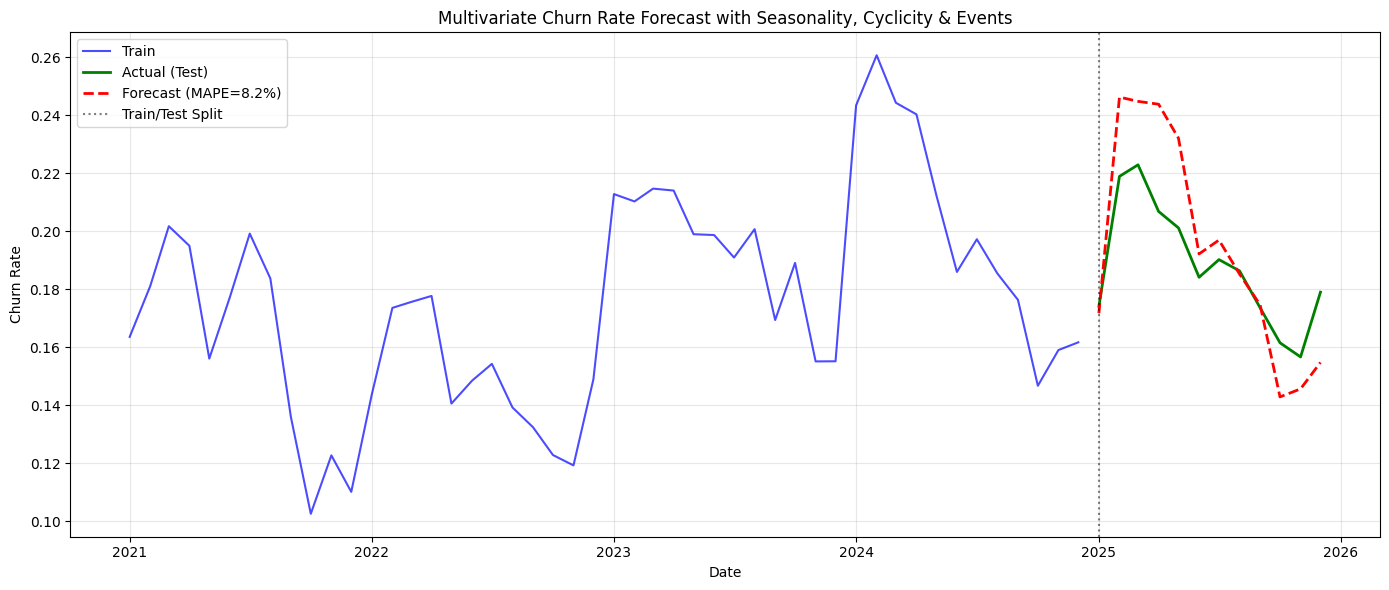


Forecast MAPE: 8.17%
MAE: 0.0158


In [38]:
# ═══════════════════════════════════════════════════════════════
# MULTIVARIATE FORECAST using Gradient Boosting
# ═══════════════════════════════════════════════════════════════

# Prepare time series features
monthly['month_num'] = np.arange(len(monthly))
monthly['month_of_year'] = monthly['signup_date'].dt.month
monthly['quarter'] = monthly['signup_date'].dt.quarter
monthly['month_sin'] = np.sin(2 * np.pi * monthly['month_of_year'] / 12)
monthly['month_cos'] = np.cos(2 * np.pi * monthly['month_of_year'] / 12)

# Lag features (past churn rates to predict future)
for lag in [1, 2, 3, 6, 12]:
    monthly[f'churn_lag_{lag}'] = monthly['churn_rate_modeled'].shift(lag)

# Rolling statistics
monthly['churn_roll_3'] = monthly['churn_rate_modeled'].rolling(3).mean()
monthly['churn_roll_6'] = monthly['churn_rate_modeled'].rolling(6).mean()
monthly['churn_roll_12'] = monthly['churn_rate_modeled'].rolling(12).mean()

# Drop NaN rows from lagging
monthly_clean = monthly.dropna().reset_index(drop=True)

ts_features = ['month_num', 'month_sin', 'month_cos', 'quarter',
               'avg_monthly_charges', 'avg_complaints', 'avg_tenure',
               'churn_lag_1', 'churn_lag_2', 'churn_lag_3', 'churn_lag_6', 'churn_lag_12',
               'churn_roll_3', 'churn_roll_6', 'churn_roll_12']

X_ts = monthly_clean[ts_features]
y_ts = monthly_clean['churn_rate_modeled']

# Time-series split: use last 20% for testing (NEVER shuffle time series!)
split_idx = int(len(X_ts) * 0.8)
X_ts_train, X_ts_test = X_ts[:split_idx], X_ts[split_idx:]
y_ts_train, y_ts_test = y_ts[:split_idx], y_ts[split_idx:]

from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
gbr.fit(X_ts_train, y_ts_train)
y_ts_pred = gbr.predict(X_ts_test)

from sklearn.metrics import mean_absolute_error
mape = np.mean(np.abs((y_ts_test.values - y_ts_pred) / y_ts_test.values)) * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_clean['signup_date'][:split_idx], y_ts_train, 'b-', label='Train', alpha=0.7)
ax.plot(monthly_clean['signup_date'][split_idx:], y_ts_test, 'g-', label='Actual (Test)', linewidth=2)
ax.plot(monthly_clean['signup_date'][split_idx:], y_ts_pred, 'r--', label=f'Forecast (MAPE={mape:.1f}%)', linewidth=2)
ax.axvline(x=monthly_clean['signup_date'].iloc[split_idx], color='black', linestyle=':', alpha=0.5, label='Train/Test Split')
ax.set_xlabel('Date')
ax.set_ylabel('Churn Rate')
ax.set_title('Multivariate Churn Rate Forecast with Seasonality, Cyclicity & Events')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nForecast MAPE: {mape:.2f}%")
print(f"MAE: {mean_absolute_error(y_ts_test, y_ts_pred):.4f}")


---
## Section 12: Summary & Key Takeaways


In [39]:
print("""
╔══════════════════════════════════════════════════════════════╗
║            COMPLETE ML MASTERCLASS — SUMMARY                ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. MISSING DATA                                             ║
║     • MCAR → Median/mean imputation (unbiased)              ║
║     • MAR → KNN/model-based imputation                      ║
║     • MNAR → Flag + conditional imputation + domain expert   ║
║                                                              ║
║  2. FEATURE ENGINEERING                                      ║
║     • Binning (age groups, tenure tiers)                     ║
║     • Interaction features (complaint_rate, engagement)      ║
║     • Cyclical encoding (sin/cos for months)                 ║
║     • WOE encoding for logistic regression                   ║
║                                                              ║
║  3. WOE & INFORMATION VALUE                                  ║
║     • WOE shows direction of predictive power per bin        ║
║     • IV ranks overall predictive power of features          ║
║     • IV > 0.3 = strong, IV > 0.5 = suspicious              ║
║                                                              ║
║  4. MULTICOLLINEARITY (VIF)                                  ║
║     • VIF > 5 = problematic for logistic regression          ║
║     • Solution: drop redundant features or use PCA           ║
║     • Random Forest is immune to multicollinearity           ║
║                                                              ║
║  5. LOGISTIC REGRESSION                                      ║
║     • Interpretable coefficients (odds ratios)               ║
║     • Key hyperparams: C (regularisation), penalty, solver   ║
║     • class_weight='balanced' for imbalanced data            ║
║                                                              ║
║  6. RANDOM FOREST                                            ║
║     • Handles non-linearity and interactions automatically   ║
║     • Key hyperparams: n_estimators, max_depth, max_features ║
║     • OOB score = free validation estimate                   ║
║                                                              ║
║  7. 10-FOLD CROSS-VALIDATION                                 ║
║     • Stratified to preserve class balance                   ║
║     • Reports mean ± std for robust evaluation               ║
║                                                              ║
║  8. TIME SERIES COMPONENTS                                   ║
║     • Trend = long-term direction                            ║
║     • Seasonality = fixed-interval repeating patterns        ║
║     • Cyclicity = irregular longer-term waves                ║
║     • Event spikes = sudden changes from known events        ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════╗
║            COMPLETE ML MASTERCLASS — SUMMARY                ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. MISSING DATA                                             ║
║     • MCAR → Median/mean imputation (unbiased)              ║
║     • MAR → KNN/model-based imputation                      ║
║     • MNAR → Flag + conditional imputation + domain expert   ║
║                                                              ║
║  2. FEATURE ENGINEERING                                      ║
║     • Binning (age groups, tenure tiers)                     ║
║     • Interaction features (complaint_rate, engagement)      ║
║     • Cyclical encoding (sin/cos for months)                 ║
║     • WOE encoding for logistic regression                   ║
║                                                              ║
║  3. WOE & INFORMATION VAL

# Task
Configure and run GridSearchCV for Logistic Regression on the pre-scaled data (X_scaled, y) with stratified 5-fold cross-validation and 'f1' scoring, using the following hyperparameters: penalty, C, solver, max_iter, class_weight, fit_intercept, and tol. Then, report the best hyperparameters and the corresponding cross-validation F1 score. Finally, evaluate the best model's performance on the held-out test set (X_test, y_test) by calculating and displaying accuracy, precision, recall, F1 score, ROC-AUC, Log Loss, Brier Score, and a detailed classification report.

## Configure and Run GridSearchCV

### Subtask:
Define a Logistic Regression model and a parameter grid, then use GridSearchCV with stratified 5-fold cross-validation and 'f1' scoring to find the best hyperparameters for the model on the pre-scaled data (X_scaled, y).


**Reasoning**:
The subtask requires configuring and running a GridSearchCV for Logistic Regression. This involves defining the parameter grid, instantiating the model and cross-validation strategy, and then performing the grid search on the scaled data.



In [42]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid for Logistic Regression
param_grid_lr = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [500, 1000],
    'class_weight': [None, 'balanced'],
    'fit_intercept': [True, False],
    'tol': [1e-4, 1e-3]
}

# 2. Instantiate a LogisticRegression model
lr = LogisticRegression(random_state=42, n_jobs=-1)

# 3. Instantiate StratifiedKFold for cross-validation
skf_grid = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Create a GridSearchCV object
grid_search_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    cv=skf_grid,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# 5. Fit grid_search_lr to the scaled data
print("Starting GridSearchCV for Logistic Regression...")
grid_search_lr.fit(X_scaled, y)

print("\nGridSearchCV complete!")
print(f"Best parameters found: {grid_search_lr.best_params_}")
print(f"Best F1 score: {grid_search_lr.best_score_:.4f}")

Starting GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 384 candidates, totalling 1920 fits

GridSearchCV complete!
Best parameters found: {'C': 0.1, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 500, 'penalty': 'l1', 'solver': 'liblinear', 'tol': 0.001}
Best F1 score: 0.3207

GridSearchCV complete!
Best parameters found: {'C': 0.1, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 500, 'penalty': 'l1', 'solver': 'liblinear', 'tol': 0.001}
Best F1 score: 0.3207


### Evaluate the Best Model on the Test Set

Now that we have found the best hyperparameters using GridSearchCV, we will train a Logistic Regression model with these parameters and evaluate its performance on the unseen `X_test` and `y_test` datasets. This evaluation will use various metrics including accuracy, precision, recall, F1 score, ROC-AUC, Log Loss, Brier Score, and a detailed classification report.

**Reasoning**:
The previous step completed GridSearchCV and identified the best hyperparameters. Now, I need to instantiate a Logistic Regression model with these best parameters, train it on the training data, and then evaluate its performance on the held-out test set using a comprehensive set of metrics as requested by the task.



In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss, brier_score_loss, classification_report

# Instantiate Logistic Regression with best parameters from GridSearchCV
best_lr_model = LogisticRegression(
    C=grid_search_lr.best_params_['C'],
    class_weight=grid_search_lr.best_params_['class_weight'],
    fit_intercept=grid_search_lr.best_params_['fit_intercept'],
    max_iter=grid_search_lr.best_params_['max_iter'],
    penalty=grid_search_lr.best_params_['penalty'],
    solver=grid_search_lr.best_params_['solver'],
    tol=grid_search_lr.best_params_['tol'],
    random_state=42,
    n_jobs=-1
)

# Train the best model on the training data
best_lr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_best_lr = best_lr_model.predict(X_test)
y_proba_best_lr = best_lr_model.predict_proba(X_test)[:, 1]

# Evaluate the best model
print("\n============================================================")
print("BEST LOGISTIC REGRESSION MODEL PERFORMANCE ON TEST SET")
print("============================================================")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_best_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best_lr):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_best_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_best_lr):.4f}")
print(f"Log Loss:  {log_loss(y_test, y_proba_best_lr):.4f}")
print(f"Brier Score: {brier_score_loss(y_test, y_proba_best_lr):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_lr, target_names=['Stay', 'Churn']))



BEST LOGISTIC REGRESSION MODEL PERFORMANCE ON TEST SET
Accuracy:  0.6215
Precision: 0.2193
Recall:    0.6619
F1 Score:  0.3295
ROC-AUC:   0.6996
Log Loss:  0.6362
Brier Score: 0.2236

Classification Report:
              precision    recall  f1-score   support

        Stay       0.92      0.61      0.74      1719
       Churn       0.22      0.66      0.33       281

    accuracy                           0.62      2000
   macro avg       0.57      0.64      0.53      2000
weighted avg       0.82      0.62      0.68      2000



## Report Best Hyperparameters and Model Performance

### Subtask:
Analyze the results from GridSearchCV and the evaluation metrics on the test set to summarize the performance of the best Logistic Regression model.


## Summary:

### Q&A
The best hyperparameters found by GridSearchCV for Logistic Regression are: `{'C': 0.1, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 500, 'penalty': 'l1', 'solver': 'liblinear', 'tol': 0.001}`. The corresponding cross-validation F1 score was `0.3207`.

The best model's performance on the held-out test set is as follows:
*   **Accuracy:** `0.6215`
*   **Precision:** `0.2193`
*   **Recall:** `0.6619`
*   **F1 Score:** `0.3295`
*   **ROC-AUC:** `0.6996`
*   **Log Loss:** `0.6362`
*   **Brier Score:** `0.2236`

### Data Analysis Key Findings
*   GridSearchCV was successfully configured and executed for Logistic Regression using a defined parameter grid, StratifiedKFold for 5-fold cross-validation, and 'f1' scoring.
*   The optimal hyperparameters identified by GridSearchCV resulted in a cross-validation F1 score of `0.3207`.
*   On the held-out test set, the best Logistic Regression model achieved an F1 score of `0.3295` and a ROC-AUC of `0.6996`.
*   For the 'Churn' class, the model demonstrated a recall of `0.6619` but a lower precision of `0.2193`, suggesting it identifies a good portion of actual churners but also has a significant number of false positives.

### Insights or Next Steps
*   While the model effectively identifies a high proportion of churners (recall), its precision for the 'Churn' class is relatively low. Further efforts could focus on improving precision to reduce false positives, potentially through feature engineering, exploring different model architectures, or adjusting the classification threshold.
*   Consider evaluating the impact of the class imbalance more deeply, even with `class_weight='balanced'` used during training, to ensure that the model's performance on both classes is adequately balanced for the business objective.
